In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")
sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm
from statsmodels.stats import contingency_tables, proportion

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

data_utils_dir = "./data_processing/data_utils"

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results" # change
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs" # change

who_variants = pd.read_csv(f"{data_utils_dir}/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

cc_df = pd.read_csv(f"{data_utils_dir}/drug_CC.csv")

model_loci = pd.read_csv(f"{data_utils_dir}/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_reuse_table_20231208.csv")
df_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv("./analysis/isolate_variants_WHO_catalog.csv.gz", compression='gzip')

In [12]:
df_geno.query("ROLLINGDB_ID=='JG00406558'")

,ROLLINGDB_ID,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
788,JG00406558,MICML,4.3.4.2,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,0.019141,4


In [14]:
isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

In [16]:
isolate_metadata.query("ROLLINGDB_ID=='KD00109931'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Num_Runs,Internal_IDs,Combined_Runs
70954,KD00109931,NaN,NaN,KD00109931,NICD,NaN,NaN,NaN,1.0,1.0,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,1,NaN,KD00109931


In [2]:
def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

    if regression:
        model_type = 'LinReg'
    else:
        model_type = 'CNN'
    
    results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
    results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]


def differences_significant_CNN_Reg(df, model, variable, direction='two-sided'):

    results_1 = df.query("Model=='CNN' & Addl_Data==@model")[variable].values
    results_2 = df.query("Model=='LinReg' & Addl_Data==@model")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

def compute_t_distribution_confidence_intervals(df, col):

    df_summary = pd.DataFrame(df.groupby(['Drug', 'Model', 'Addl_Data'])[col].agg(['mean', 'std', 'count'])).reset_index().rename(columns={'mean': col})
    
    df_summary[f'{col}_LB'] = df_summary[col] + st.t.ppf(0.025, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])
    df_summary[f'{col}_UB'] = df_summary[col] + st.t.ppf(0.975, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])

    assert len(df_summary.query(f"{col} < {col}_LB")) == 0
    assert len(df_summary.query(f"{col} > {col}_UB")) == 0

    return df_summary

# Break down model performance by primary lineage

In [3]:
df_results_by_lineage = []
df_pred_by_lineage = []

for drug in drugs_lst:
    
    if drug == 'BDQ':
        model_dir = f"{results_dir}/{drug}_augment_lineage_amino_acid"
    elif drug == 'PZA':
        model_dir = f"{results_dir}/{drug}_amino_acid"
    else:
        model_dir = f"{results_dir}/{drug}_lineage_amino_acid"
        
    # df_results = pd.read_csv(f"{model_dir}/results.csv")

    df_pred = pd.read_csv(f"{model_dir}/test_predictions.csv").query("Span_CC==0").reset_index(drop=True)
    df_pred = df_pred.merge(df_geno[['ROLLINGDB_ID', 'Lineage']].rename(columns={'ROLLINGDB_ID': 'Isolate'}), how='left')
    assert sum(pd.isnull(df_pred['Lineage'])) == 0
    df_pred['y_pred_exp'] = np.exp2(df_pred['y_pred'])

    df_pred.loc[(df_pred['lower'] <= df_pred['y_pred_exp']) & (df_pred['y_pred_exp'] <= df_pred['upper']), 'Compute_Error'] = 0
    df_pred['Compute_Error'] = df_pred['Compute_Error'].fillna(1).astype(int)

    df_pred.loc[(df_pred['y_pred_exp'] < df_pred['lower']), 'Bound_for_Error'] = df_pred['lower']
    df_pred.loc[(df_pred['y_pred_exp'] > df_pred['upper']), 'Bound_for_Error'] = df_pred['upper']
    df_pred.loc[df_pred['upper']==np.inf, 'Bound_for_Error'] = df_pred['lower']

    df_pred['Error'] = np.abs(df_pred['y_pred'] - np.log2(df_pred['Bound_for_Error']))
    assert len(df_pred.loc[pd.isnull(df_pred['Error'])].query("Compute_Error==1")) == 0
    df_pred.loc[df_pred['Compute_Error']==0, 'Error'] = 0

    df_pred['Error'] = df_pred['Error'].fillna(0)

    # binned_mae, binned_mse, within_doubling = boundedLoss_predict(df_pred, y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")

    # assert binned_mae == df_pred['Error'].mean()
    
    df_MAE_disaggregated = pd.DataFrame(df_pred.groupby('Lineage')['Error'].mean())

    df_MAE_disaggregated = df_MAE_disaggregated.merge(pd.DataFrame(df_pred.Lineage.value_counts()), left_index=True, right_index=True)

    df_MAE_disaggregated.loc['Total', :] = [df_pred['Error'].mean(), len(df_pred)]
    
    df_MAE_disaggregated['Drug'] = drug
    df_pred['Drug'] = drug

    df_results_by_lineage.append(df_MAE_disaggregated)
    df_pred_by_lineage.append(df_pred)
    
df_pred_by_lineage = pd.concat(df_pred_by_lineage).reset_index(drop=True)
df_results_by_lineage = pd.concat(df_results_by_lineage).reset_index()

In [4]:
df_results_by_lineage.query("count >= 5").shape, df_results_by_lineage.shape

((38, 4), (51, 4))

<Axes: xlabel='Drug', ylabel='Error'>

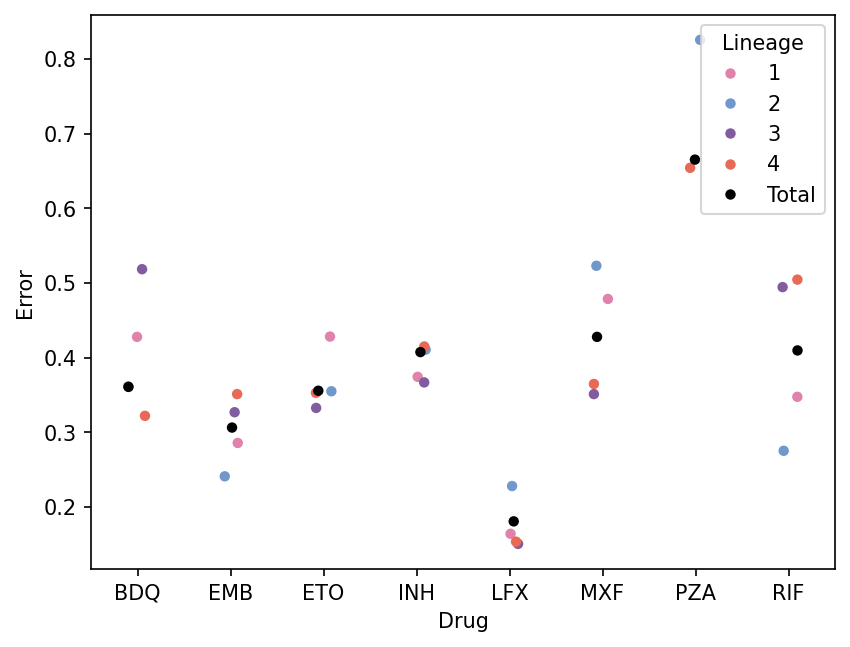

In [5]:
LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   "Total": "black"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

sns.stripplot(data=df_results_by_lineage.query("count >= 5"),
          x='Drug',
              y='Error',
          hue='Lineage',
              palette=LinToColor_Dict,
         )

In [6]:
df_pred_by_lineage_count_filt = df_pred_by_lineage.merge(df_results_by_lineage.query("count >= 5")[['Drug', 'Lineage']])

In [7]:
df_pred_by_lineage_count_filt.query("Lineage=='1'").Drug.unique()

array(['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'RIF'], dtype=object)

In [10]:
# Loop over unique lineages
for drug in drugs_lst:
    
    print(f"\n{drug}")
    
    df_single_drug = df_pred_by_lineage_count_filt.query("Drug==@drug")

    for lineage in df_single_drug['Lineage'].unique():
        
        lineage_errors = df_single_drug.loc[df_single_drug['Lineage'] == lineage, 'Error'].values

        # Welch's t-test
        # _, p = st.ttest_ind(lineage_errors, df_single_drug['Error'].values, equal_var=False, alternative='two-sided')
        
        # Mann-Whitney U test
        _, p = st.mannwhitneyu(lineage_errors, df_single_drug['Error'].values, alternative='two-sided')

        # results.append({'Lineage': lineage, 'U_stat': stat, 'p_value': p})
        if p <= 0.05:
            print(lineage, np.round(p, 4), np.round(np.mean(lineage_errors), 3), np.round(df_single_drug.Error.mean(), 3))


BDQ
3 0.0003 0.518 0.36

EMB
4 0.0176 0.351 0.306
2 0.0025 0.241 0.306

ETO

INH

LFX
2 0.0287 0.228 0.181

MXF
2 0.0217 0.523 0.428

PZA
2 0.0249 0.826 0.668

RIF
4 0.0002 0.504 0.409
2 0.0 0.275 0.409


# Compare XGBoost model performance

In [10]:
model_dir = f"{results_dir}/RIF_lineage_amino_acid"

df_CNN = pd.read_csv(f"{model_dir}/results.csv")
df_XGBoost = pd.read_csv(f"{model_dir}/xgboost/custom_loss/results.csv")
df_LinReg = pd.read_csv(f"{model_dir}/ridge/results.csv")

In [12]:
metrics_to_compare = ['Binned_MAE', 'Within_doubling', 'F1', 'Balanced_Acc']

for col in metrics_to_compare:
    
    if col == 'Binned_MAE':
        alt = 'less'
    else:
        alt = 'greater'
    
    _, pval = st.ttest_ind(df_CNN[col], df_XGBoost[col], alternative=alt, equal_var=False)
    
    print(col, np.round(pval, 4))

Binned_MAE 0.0
Within_doubling 0.0
F1 0.0001
Balanced_Acc 0.0001


In [13]:
metrics_to_compare = ['Binned_MAE', 'Binned_MSE', 'Within_doubling', 'F1', 'Balanced_Acc']

for col in metrics_to_compare:
    
    if col in ['Binned_MAE', 'Binned_MSE']:
        alt = 'less'
    else:
        alt = 'greater'
    
    _, pval = st.ttest_ind(df_LinReg[col], df_XGBoost[col], alternative=alt, equal_var=False)
    
    print(col, np.round(pval, 4), np.round(df_LinReg[col].mean(), 6), np.round(df_XGBoost[col].mean(), 6))

Binned_MAE 0.0891 0.607572 0.613125
Binned_MSE 0.0049 1.710829 1.820782
Within_doubling 0.9667 0.809974 0.816739
F1 0.0007 0.971433 0.96859
Balanced_Acc 0.0006 0.971831 0.96905


In [18]:
col = 'Within_doubling'
st.ttest_ind(df_LinReg[col], df_XGBoost[col], alternative='less', equal_var=False)

TtestResult(statistic=-2.2400294548872703, pvalue=0.033258578365211046, df=5.976589605142391)

In [29]:
df_XGBoost[col].mean(), df_LinReg[col].mean()

(0.8167389418907197, 0.8099739809193409)

In [17]:
col = 'Binned_MAE'
st.ttest_ind(df_LinReg[col], df_XGBoost[col], alternative='less', equal_var=False)

TtestResult(statistic=-1.4810547486960188, pvalue=0.08906810492564686, df=7.735077634334336)

# Compute Essential Agreement across all drugs

In [41]:
df_test_set_results = pd.DataFrame(columns = ['Drug', 'MAE', 'EA', 'NumLogs'])
i = 0

for drug in drugs_lst:

    if drug == 'PZA':
        model = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        model = f"{drug}_augment_lineage_amino_acid"
    else:
        model = f"{drug}_lineage_amino_acid"

    df_full = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv").query("category=='test_set' & Span_CC==0")

    print(model, len(df_full))

    df_pred = pd.read_csv(f"{results_dir}/{model}/test_predictions.csv")
    
    # number of log2s that the MICs span. Larger spans make essential agreements harder since essential agreement is within 1 doubling
    num_logs = int(df_pred.y_test.max()) - int(df_pred.y_test.min())
    
    # get EA for the test set isolates
    mae, mse, within_doubling = boundedLoss_predict(df_pred.query("Isolate in @df_full.ROLLINGDB_ID"), y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")
    
    df_test_set_results.loc[i, :] = [drug, mae, within_doubling, num_logs]
    i += 1

BDQ_augment_lineage_amino_acid 1826
EMB_lineage_amino_acid 1997
ETO_lineage_amino_acid 2024
INH_lineage_amino_acid 2414
LFX_lineage_amino_acid 1560
MXF_lineage_amino_acid 1885
PZA_amino_acid 205
RIF_lineage_amino_acid 2306


In [60]:
df_pred['y_pred_exp'] = np.exp2(df_pred['y_pred'])
val_range = np.max(df_pred['y_pred_exp']) - np.min(df_pred['y_pred_exp'])
val_range

97.39711504007997

In [61]:
0.1*val_range

9.739711504007998

In [62]:
df_pred.

,Isolate,y_test,lower,upper,Span_CC,y_pred,y_pred_exp
0,SAMEA104362050,-3.473931,0.06,0.12,0,-4.035580,0.060977
1,SAMEA104362052,-5.058894,0.00,0.06,0,-4.143262,0.056592
2,SAMEA104362055,-5.058894,0.00,0.06,0,-4.984200,0.031594
3,SAMEA104362061,-5.058894,0.00,0.06,0,-4.143262,0.056592
4,SAMEA104362065,2.000000,4.00,inf,0,5.825643,56.714412
...,...,...,...,...,...,...,...
2364,TRL0095895,-0.434403,0.48,1.00,1,-4.016479,0.061790
2365,TRL0115412,-0.434403,0.48,1.00,1,-3.975904,0.063553
2366,TRL0116115,-0.434403,0.48,1.00,1,-4.027418,0.061323
2367,TRL0116714,-0.434403,0.48,1.00,1,-0.463803,0.725072


In [42]:
df_test_set_results.MAE.min(), df_test_set_results.MAE.max()

(0.18052592807826376, 0.6651593454232579)

In [43]:
df_test_set_results.EA.min(), df_test_set_results.EA.max(), df_test_set_results.EA.mean()

(0.7902439024390244, 0.9294871794871795, 0.8864257253373096)

In [48]:
df_test_set_results['EA_NumLogs'] = df_test_set_results['EA'] * df_test_set_results['NumLogs']

In [49]:
df_test_set_results.sort_values('EA_NumLogs', ascending=False)

,Drug,MAE,EA,NumLogs,EA_NumLogs
7,RIF,0.409519,0.900694,15,13.510408
3,INH,0.407315,0.887738,13,11.540597
5,MXF,0.427694,0.856233,10,8.562334
1,EMB,0.306202,0.912869,9,8.215824
0,BDQ,0.360679,0.92333,8,7.386637
4,LFX,0.180526,0.929487,7,6.50641
2,ETO,0.35554,0.89081,7,6.235672
6,PZA,0.665159,0.790244,6,4.741463


In [63]:
df_test_set_results.sort_values('EA', ascending=False)

,Drug,MAE,EA,NumLogs,EA_NumLogs
4,LFX,0.180526,0.929487,7,6.50641
0,BDQ,0.360679,0.92333,8,7.386637
1,EMB,0.306202,0.912869,9,8.215824
7,RIF,0.409519,0.900694,15,13.510408
2,ETO,0.35554,0.89081,7,6.235672
3,INH,0.407315,0.887738,13,11.540597
5,MXF,0.427694,0.856233,10,8.562334
6,PZA,0.665159,0.790244,6,4.741463


# Compute Essential Agreement on CRyPTIC Only to compare to https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012260

In [85]:
df_EA = pd.DataFrame(columns = ['Drug', 'EA', 'sample_size_CNN'])
i = 0

for drug in drugs_lst:

    if drug == 'PZA':
        model = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        model = f"{drug}_augment_lineage_amino_acid"
    else:
        model = f"{drug}_lineage_amino_acid"

    df_full = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")
    cryptic_samples = df_full.query("DB_OF_ORIGIN=='CRyPTIC' & category=='test_set'").ROLLINGDB_ID.values

    print(model, len(cryptic_samples))

    if len(cryptic_samples) > 0:
        
        # for cv in np.arange(len(glob.glob(f"{results_dir}/{model}/cross_validation/test_predictions_*.csv"))):
        #     df_pred = pd.read_csv(f"{results_dir}/{model}/cross_validation/test_predictions_{cv}.csv")
        #     _, _, within_doubling = boundedLoss_predict(df_pred.query("Isolate in @cryptic_samples"), y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")
        #     df_EA.loc[i, :] = [drug, cv, within_doubling]
        #     i += 1
        
        df_pred = pd.read_csv(f"{results_dir}/{model}/test_predictions.csv")
        
        _, _, within_doubling = boundedLoss_predict(df_pred.query("Isolate in @cryptic_samples"), y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")
        df_EA.loc[i, :] = [drug, within_doubling, len(df_pred.query("Isolate in @cryptic_samples"))]

        i += 1
            
# df_EA['Addl_Data'] = 'Final'
# df_EA['Model'] = 'CNN'

BDQ_augment_lineage_amino_acid 1726
EMB_lineage_amino_acid 1515
ETO_lineage_amino_acid 1761
INH_lineage_amino_acid 1869
LFX_lineage_amino_acid 1549
MXF_lineage_amino_acid 1349
PZA_amino_acid 0
RIF_lineage_amino_acid 1720


In [104]:
# df_EA_CIs = compute_t_distribution_confidence_intervals(df_EA, 'EA')

df_EA_cryptic = pd.DataFrame({'Drug': ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'RIF'], 
                              'sample_size_cryptic': [2130, 1907, 2210, 2380, 1936, 1699, 2246],
                              'EA_cryptic': [0.933, 0.950, 0.913, 0.942, 0.949, 0.909, 0.929],
                              # 'EA_cryptic_LB': [0.923, 0.94, 0.901, 0.932, 0.940, 0.895, 0.919],
                              # 'EA_cryptic_UB': [0.944, 0.96, 0.924, 0.951, 0.959, 0.922, 0.94]
                             })

df_EA_cryptic = df_EA_cryptic.merge(df_EA, on='Drug')
df_EA_cryptic['diff'] = df_EA_cryptic['EA_cryptic'] - df_EA_cryptic['EA']

df_EA_cryptic['Num_within_doubling_cryptic'] = (df_EA_cryptic['EA_cryptic'] * df_EA_cryptic['sample_size_cryptic']).astype(int)
df_EA_cryptic['Num_within_doubling_CNN'] = (df_EA_cryptic['EA'] * df_EA_cryptic['sample_size_CNN']).astype(int)

df_EA_cryptic['Drug'] = df_EA_cryptic['Drug'].map(abbr_drug_dict)

In [106]:
df_EA_cryptic.sort_values('EA_cryptic', ascending=False)

,Drug,sample_size_cryptic,EA_cryptic,EA,sample_size_CNN,diff,Num_within_doubling_cryptic,Num_within_doubling_CNN
1,Ethambutol,1907,0.950,0.943894,1515,0.006106,1811,1430
4,Levofloxacin,1936,0.949,0.928986,1549,0.020014,1837,1439
3,Isoniazid,2380,0.942,0.925094,1869,0.016906,2241,1729
0,Bedaquiline,2130,0.933,0.937428,1726,-0.004428,1987,1618
6,Rifampicin,2246,0.929,0.959302,1720,-0.030302,2086,1650
2,Ethionamide,2210,0.913,0.906871,1761,0.006129,2017,1597
5,Moxifloxacin,1699,0.909,0.881394,1349,0.027606,1544,1189


In [107]:
df_EA_cryptic.query("Drug != 'PZA'").EA.mean(), df_EA_cryptic.query("Drug != 'PZA'").EA_cryptic.mean()

(0.9261384414195103, 0.9321428571428572)

In [108]:
for i, row in df_EA_cryptic.iterrows():
    
    drug = row['Drug']
    
    # cryptic first, then CNN
    total_samples = [df_EA_cryptic.query("Drug==@drug")['sample_size_cryptic'].values[0], df_EA_cryptic.query("Drug==@drug")['sample_size_CNN'].values[0]]
    num_within_1_doubling = [df_EA_cryptic.query("Drug==@drug")['Num_within_doubling_cryptic'].values[0], df_EA_cryptic.query("Drug==@drug")['Num_within_doubling_CNN'].values[0]]

    _, pval_xgboost_better = proportion.proportions_ztest(count=num_within_1_doubling, 
                                                         nobs=total_samples,
                                                         alternative='larger'
                                                        )
    
    _, pval_CNN_better = proportion.proportions_ztest(count=num_within_1_doubling, 
                                                         nobs=total_samples,
                                                         alternative='smaller'
                                                        )
    
    df_EA_cryptic.loc[i, ['pval_xgboost_higher', 'pval_CNN_higher']] = [pval_xgboost_better, pval_CNN_better]
    
# df_EA_cryptic.to_csv("../results/EA_cryptic_data.csv", index=False)

In [109]:
df_EA_cryptic.query("pval_xgboost_higher <= 0.05").sort_values('pval_xgboost_higher')[['Drug', 'EA', 'EA_cryptic', 'pval_xgboost_higher', 'pval_CNN_higher']]

,Drug,EA,EA_cryptic,pval_xgboost_higher,pval_CNN_higher
5,Moxifloxacin,0.881394,0.909,0.006830,0.993170
4,Levofloxacin,0.928986,0.949,0.007029,0.992971
3,Isoniazid,0.925094,0.942,0.015551,0.984449


In [110]:
# difference in percentage points
df_EA_cryptic['diff'].mean()*100, df_EA_cryptic['diff'].median()*100

(0.6004415723346835, 0.6128904031800109)

In [127]:
df_EA_cryptic

,Drug,sample_size_cryptic,EA_cryptic,EA,sample_size_CNN,diff,Num_within_doubling_cryptic,Num_within_doubling_CNN,pval_xgboost_higher,pval_CNN_higher
0,Bedaquiline,2130,0.933,0.937428,1726,-0.004428,1987,1618,0.716077,0.283923
1,Ethambutol,1907,0.950,0.943894,1515,0.006106,1811,1430,0.227114,0.772886
2,Ethionamide,2210,0.913,0.906871,1761,0.006129,2017,1597,0.262835,0.737165
3,Isoniazid,2380,0.942,0.925094,1869,0.016906,2241,1729,0.015551,0.984449
4,Levofloxacin,1936,0.949,0.928986,1549,0.020014,1837,1439,0.007029,0.992971
5,Moxifloxacin,1699,0.909,0.881394,1349,0.027606,1544,1189,0.006830,0.993170
6,Rifampicin,2246,0.929,0.959302,1720,-0.030302,2086,1650,0.999977,0.000023


In [132]:
st.wilcoxon(df_EA_cryptic['EA_cryptic'], 
            df_EA_cryptic['EA'], 
            alternative='greater'
           )

WilcoxonResult(statistic=20.0, pvalue=0.1875)

# Quantitative Model Comparison

In [3]:
def get_all_single_drug_models(drug, regression=False, binary=False):
    '''
    This function gets all the models for a given drug that have model results
    '''
    
    if binary:
        single_drug_results_dir = os.path.join(results_dir, f"{drug}_binary")
    else:
        single_drug_results_dir = os.path.join(results_dir, f"{drug}")
    
    # gets all directories with the drug name
    CNN_fNames = glob.glob(f"{single_drug_results_dir}*/results.csv")
    
    # if regression or bootstrap, then all directories must also have those corresponding directories. The regression script performs bootstrapping, so don't need to check them separately
    if regression:
        regression_fNames = glob.glob(os.path.join(results_dir, f"{single_drug_results_dir}*/ridge/results.csv"))
    else:
        regression_fNames = []
        
    df_combined = []
    
    for fName in CNN_fNames + regression_fNames:
        
        # these get included by the search, even if not searching for binary, so manually exclude
        if not binary and 'binary' in fName:
            continue
        
        df = pd.read_csv(fName)

        model_name = '– Lineage'

        num_addl_features = 0

        if 'lineage' in fName:
            model_name = '+ Lineage'
            num_addl_features += 1

        if 'amino_acid' not in fName:
            model_name += '\n– AA Properties'
            num_addl_features += 1

        if 'tier2' in fName:
            model_name += '\n+ Tier 2 Loci'
            num_addl_features += 1

        if '_AF25' in fName:
            model_name += '\nAF = 25%'
            num_addl_features += 1
        # else:
        #     model_name += '\n AF = 75%'

        if 'augment' in fName:
            model_name += '\nBinary Augment'
            num_addl_features += 1
            
        if 'binary' in fName:
            model_name += '\nBinary'
            num_addl_features += 1

        # remove leading newline characters
        model_name = model_name.lstrip()

        df['Addl_Data'] = model_name
        
        if 'Model' not in df.columns:
            df['Model'] = ['Reg' if 'ridge' in fName else 'CNN'][0]
        
        df_combined.append(df)

    df_combined = pd.concat(df_combined)

    # check no duplicate row identifiers
    assert len(df_combined[['Model', 'Addl_Data', 'CV']].drop_duplicates()) == len(df_combined)
        
    # exponentiate errors
    if not binary:
        for col in ['Binned_MAE', 'Binned_MSE']:
            df_combined[f'{col}_exp'] = np.exp2(df_combined[col])

        # add without doubling
        df_combined['Without_doubling'] = 1 - df_combined['Within_doubling']

    return df_combined

In [24]:
# df_combined_all_drugs = pd.concat([get_all_single_drug_models(drug, regression=True, binary=False) for drug in drugs_lst])

# df_combined_all_drugs['Model'] = df_combined_all_drugs['Model'].replace('Reg', 'LinReg')

# df_combined_all_drugs['Drug'] = df_combined_all_drugs['Drug'].map(abbr_drug_dict)

# plotting_order = df_combined_all_drugs.sort_values(['Drug', 'Model', 'Addl_Data'], ascending=[True, False, False]).groupby(['Drug', 'Model', 'Addl_Data'], sort=False).Binned_MAE.mean().index.values

# df_combined_all_drugs.to_csv("./supplement/quant_model_results.csv", index=False)

df_combined_all_drugs = pd.read_csv("./supplement/quant_model_results.csv")

In [5]:
df_combined_all_drugs.query("Model=='CNN'").groupby('Drug')['Within_doubling'].mean()

Drug
Bedaquiline     0.923686
Ethambutol      0.906009
Ethionamide     0.888192
Isoniazid       0.884797
Levofloxacin    0.926538
Moxifloxacin    0.824881
Pyrazinamide    0.756098
Rifampicin      0.897485
Name: Within_doubling, dtype: float64

In [6]:
df_combined_all_drugs.query("Model=='CNN'").groupby('Drug')['Within_doubling'].mean().mean()

0.8759606079428783

In [7]:
df_combined_all_drugs.Addl_Data.unique()

array(['– Lineage', '– Lineage\nBinary Augment',
       '+ Lineage\nBinary Augment', '+ Lineage',
       '+ Lineage\n+ Tier 2 Loci', '– Lineage\n+ Tier 2 Loci',
       '– Lineage\n– AA Properties', '+ Lineage\n– AA Properties'],
      dtype=object)

In [12]:
drug = 'Rifampicin'

df_combined_all_drugs.query("Drug==@drug").Addl_Data.unique()

array(['– Lineage', '+ Lineage'], dtype=object)

In [16]:
df_combined_all_drugs.query("Drug==@drug").groupby(['Model', 'Addl_Data'])['Binned_MAE'].mean()

Model   Addl_Data
CNN     + Lineage    0.418223
        – Lineage    0.413947
LinReg  + Lineage    0.607572
        – Lineage    0.595128
Name: Binned_MAE, dtype: float64

In [22]:
df_combined_all_drugs.query("Drug=='Pyrazinamide' & Model=='CNN' & ~Addl_Data.str.contains('Tier 2') & ~Addl_Data.str.contains('Augment')").groupby('Addl_Data').Binned_MAE.mean()

Addl_Data
+ Lineage                     0.757035
+ Lineage\n– AA Properties    0.942820
– Lineage                     0.682616
– Lineage\n– AA Properties    1.012889
Name: Binned_MAE, dtype: float64

In [5]:
def single_metric_forest_plot(df, col_name, xlabel_name, models_lst, convert_to_percent=False, saveName=None, legend_loc=None):

    df_summary = df.copy()
    
    offset = 0.25
    y_pos = np.arange(df_summary.Drug.nunique())
    
    # colors = dict(zip(['CNN', 'LinReg', 'Catalog'], sns.color_palette("Set2", n_colors=3).as_hex()))
    colors = dict(zip(["CNN", "LinReg", "Catalog"], [sns.color_palette("Set2").as_hex()[0], sns.color_palette("Set2").as_hex()[1], sns.color_palette("Set2").as_hex()[1]]))

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 3.5))

    if convert_to_percent:
        df_summary[[col_name, f'{col_name}_LB', f'{col_name}_UB']] *= 100
    
    # Plot each model (CNN, regression, catalog), separately with a dodge
    for i, model in enumerate(models_lst):
        
        model_data = df_summary.query("Model==@model")
        
        ax.errorbar(
            model_data[col_name], 
            y_pos + (i - len(models_lst) / 2) * offset,  # Dodge the y-position
            xerr=[
                model_data[col_name] - model_data[f'{col_name}_LB'], 
                model_data[f'{col_name}_UB'] - model_data[col_name]
            ],
            fmt='o', 
            markersize=5,
            label=model,  # Use model name as the legend label
            elinewidth=1, 
            capsize=3,
            color=colors[model],
        )
    
    # Customize the plot
    # ax.set_xlim(right=1)
    
    if convert_to_percent:
        plt.xlim(right=100)
    # else:
    #     plt.xlim(left=0, right=1)
        
    ax.set_yticks(y_pos)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(list(model_data.Drug.unique()), fontsize=9)
    ax.set_xlabel(xlabel_name)
    # ax.set_title("Specificity of Binary and Quantiative CNN Models")
    ax.invert_yaxis()  # Invert y-axis to have the first study at the top
    
    if legend_loc is not None:
        ax.legend(title="", fontsize=9, loc=legend_loc)
    else:
        ax.legend(title="", fontsize=9)
    
    # Show the plot
    sns.despine()
    plt.tight_layout()

    if saveName is not None:
        plt.savefig(saveName, format='svg')
    else:
        plt.show()

In [27]:
def plot_single_drug_model_comparison(drug, df_combined, binary=False, plot_col='Binned_MAE', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    # color_palette = dict(zip(["CNN", "LinReg", "Catalog"], sns.color_palette("Set2").as_hex()))
    if binary:
        reg_col = 'LogReg'
    else:
        reg_col = 'LinReg'

    color_palette = dict(zip(["CNN", reg_col, "Catalog"], [sns.color_palette("Set2").as_hex()[0], sns.color_palette("Set2").as_hex()[1], sns.color_palette("Set2").as_hex()[1]]))

    if model_order is None:
        model_order = ['– Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    # df_combined['Model'] = df_combined['Model'].replace('LinReg', 'Regression')

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=[reg_col, 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate([reg_col, 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    plt.legend(title='', fontsize=ref_font_size-1, loc='best', ncols=2)
    
    # try:
    #     ax.get_legend().remove()
    # except:
    #     pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

In [22]:
def get_performance_comparison_CNN_Reg(drug, df_combined, model_order=None, plot_col='Binned_MAE', y_min=None, saveName=None):
    
    # df_combined = get_all_single_drug_models(drug, regression=True)
    
    if model_order is None:
        # model_order = ['- Lineage', '+ Lineage', '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci'] #['+AA Properties', '+Lineage\n+AA Properties']
        model_order = df_combined.Addl_Data.unique()

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")
    
    if 'exp' in plot_col.lower():
        # plot_y_min = 1
        title = 'Mean Absolute Error (Doublings)'
        ylabel = 'Relative Error'
        save_name = 'MAE_exp'
    elif 'doubling' in plot_col.lower():
        # plot_y_min = 0
        title = 'Essential Disagreement'
        ylabel = 'Essential Disagreement'
        save_name = 'EA'
    elif plot_col in ['Spearman', 'Pearson']:
        ylabel = plot_col
        title = plot_col
        # plot_y_min = 0.5
        save_name = plot_col
    else:
        # plot_y_min = 0
        title = 'Mean Absolute Error'
        ylabel = 'Mean Absolute Error (log2-MIC)'
        save_name = 'MAE'

    if '- Lineage\n+ Tier 2 Loci' in model_order:
        save_name += "_tier2"

    # # override
    # if y_min is not None:
    #     plot_y_min = y_min

    plot_single_drug_model_comparison(drug, df_combined, plot_col=plot_col, model_order=model_order, mean_bar_width=0.15, y_min=y_min, ylabel=ylabel, title=title, saveName=saveName)        
            
    df_pvals = pd.DataFrame(columns=['Model', 'Variable', 'CNN_better_pval', 'Reg_better_pval', 'Two_sided_pval'])
    i = 0

    for model in df_combined.Addl_Data.unique():
        
        df_pvals.loc[i, :] = [model.replace('\n', ','), 
                              plot_col, 
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='less'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='greater'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='two-sided')
                             ]
        i += 1
        
        if plot_col != 'Without_doubling':
            df_pvals.loc[i, :] = [model.replace('\n', ','), 
                                  'Without_doubling',
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='less'),
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='greater'),
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='two-sided')
                                 ]
            i += 1

    # # perform FDR correction at the single-drug level
    # _, cnn_better_bh_pvals, _, _ = sm.multipletests(df_pvals['CNN_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_CNN_better_pval'] = cnn_better_bh_pvals
    
    # _, reg_better_bh_pvals, _, _ = sm.multipletests(df_pvals['Reg_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_Reg_better_pval'] = reg_better_bh_pvals
    
    df_pvals['Drug'] = drug
    
    return df_pvals

# 0. Compare +/- Augmentation for Bedaquiline

BDQ


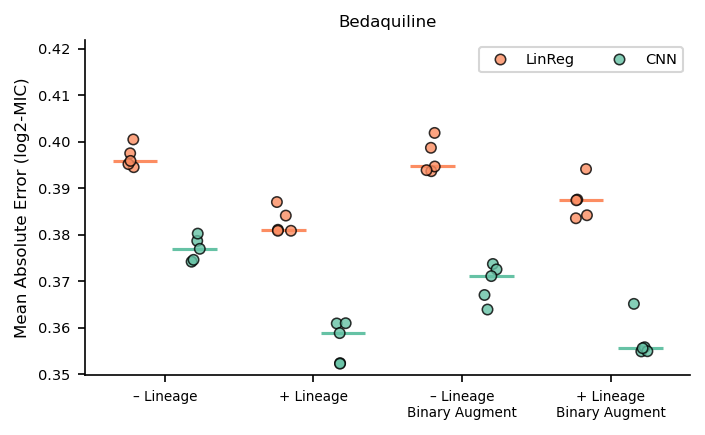

In [17]:
for drug in os.listdir(data_dir):

    if drug in ['BDQ']:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        model_order = ['– Lineage', '+ Lineage', '– Lineage\nBinary Augment', '+ Lineage\nBinary Augment']
        
        _ = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = model_order,
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE_augment_compare.svg"
                                                     )

In [63]:
# does binary augmentation significantly improve without lineage
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '– Lineage\nBinary Augment', '– Lineage', 'Binned_MAE', regression=False, direction='less')

0.006319066577618547

In [64]:
# does binary augmentation significantly improve with lineage
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '+ Lineage\nBinary Augment', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

0.5276637505602293

In [22]:
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=0.364017422980435, pvalue=0.6370094650566578, df=7.4326209052525085)

In [25]:
# for BDQ, remove the unaugmented cases
df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='Bedaquiline') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]

df_combined_all_drugs['Addl_Data'] = df_combined_all_drugs['Addl_Data'].str.replace('\nBinary Augment', '')

# 1. Does lineage improve MAE?

In [27]:
for drug in drugs_lst:
    
    full_drug_name = abbr_drug_dict[drug]
        
    lineage_better_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='greater')
    lineage_worse_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

    with_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '+ Lineage' & Model=='CNN'").Binned_MAE.mean()
    no_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '– Lineage' & Model=='CNN'").Binned_MAE.mean()

    if lineage_better_pval <= 0.05:
        print(f"{full_drug_name}: + Lineage better, pval = {lineage_better_pval}, Δ = {with_lineage_MAE - no_lineage_MAE}")
    elif lineage_worse_pval <= 0.05:
        print(f"{full_drug_name}: + Lineage worse, pval = {lineage_worse_pval} Δ = {with_lineage_MAE - no_lineage_MAE}")
    else:
        # two_sided_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='two-sided')

        print(f"{full_drug_name}: No difference, pval = {lineage_better_pval}")

Bedaquiline: + Lineage better, pval = 0.0008807018106231542, Δ = -0.012386062625521443
Ethambutol: + Lineage better, pval = 0.03560671906860689, Δ = -0.003902499979236307
Ethionamide: + Lineage better, pval = 0.0014894351577719482, Δ = -0.026060629118770884
Isoniazid: No difference, pval = 0.23240999449358896
Levofloxacin: + Lineage better, pval = 0.0010001735887700037, Δ = -0.00615761516394861
Moxifloxacin: + Lineage better, pval = 1.4986398413119178e-09, Δ = -0.08998945603241615
Pyrazinamide: + Lineage worse, pval = 0.018434829160430533 Δ = 0.07441862412642752
Rifampicin: No difference, pval = 0.9102903404393828


In [ ]:
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.05, 'Asterisk'] = '*'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.01, 'Asterisk'] = '**'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.001, 'Asterisk'] = '***'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.0001, 'Asterisk'] = '****'

In [13]:
st.ttest_ind(df_combined_all_drugs.query("Drug=='Ethambutol' & Model=='CNN' & Addl_Data in ['– Lineage']").Binned_MAE,
             df_combined_all_drugs.query("Drug=='Ethambutol' & Model=='CNN' & Addl_Data in ['+ Lineage']").Binned_MAE,
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=2.121775725335579, pvalue=0.03560671906860689, df=7.057600397381599)

In [15]:
st.ttest_ind(df_combined_all_drugs.query("Drug=='Pyrazinamide' & Model=='CNN' & Addl_Data in ['– Lineage']").Binned_MAE,
             df_combined_all_drugs.query("Drug=='Pyrazinamide' & Model=='CNN' & Addl_Data in ['+ Lineage']").Binned_MAE,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-2.5965019161941303, pvalue=0.018434829160430533, df=6.726651877158774)

BDQ
EMB
ETO
INH
LFX
MXF
PZA
RIF


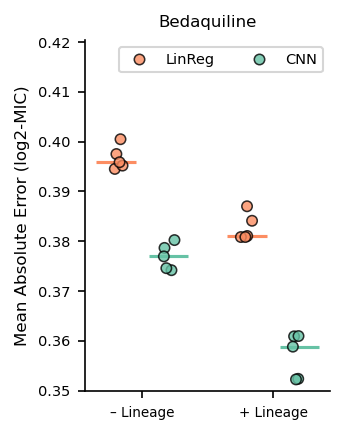

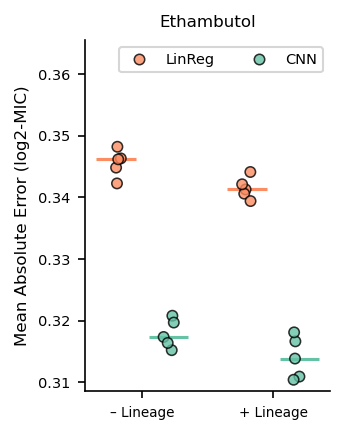

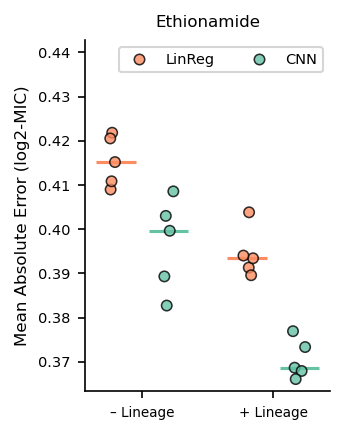

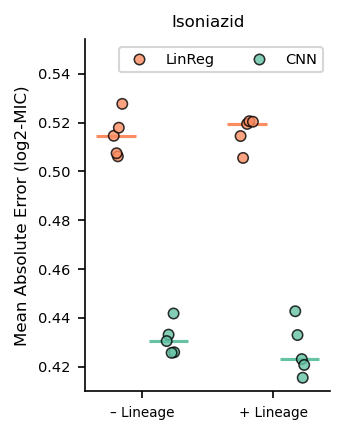

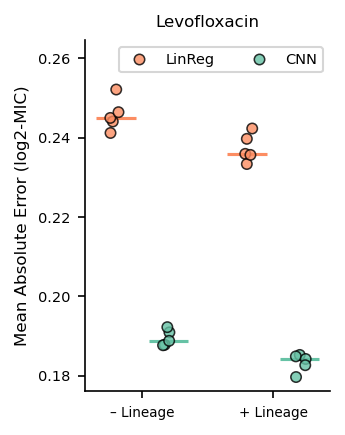

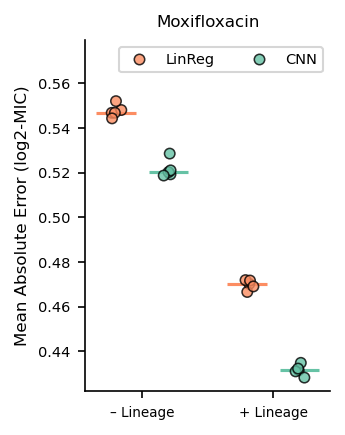

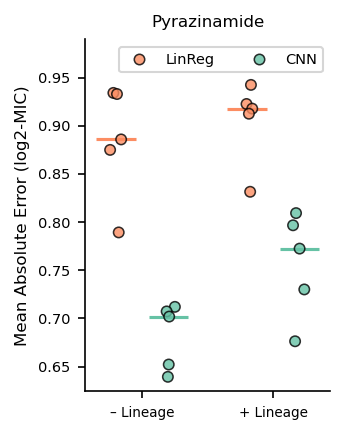

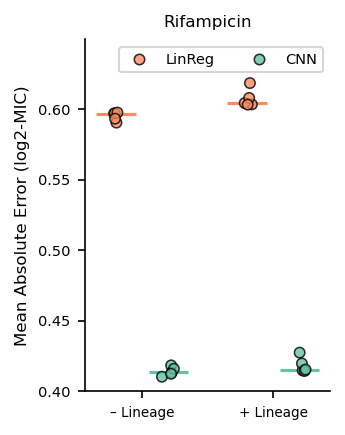

In [30]:
df_pvals_combined = []

for drug in os.listdir(data_dir):

    if drug in drugs_lst:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        df_pvals = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = ['– Lineage', '+ Lineage'],
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE.svg"
                                                     )
        df_pvals_combined.append(df_pvals)

df_pvals_combined = pd.concat(df_pvals_combined)

BDQ
EMB
ETO
INH
LFX
MXF
PZA
RIF


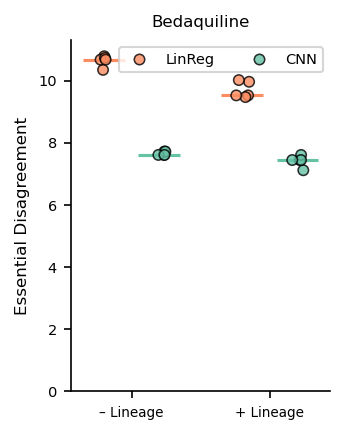

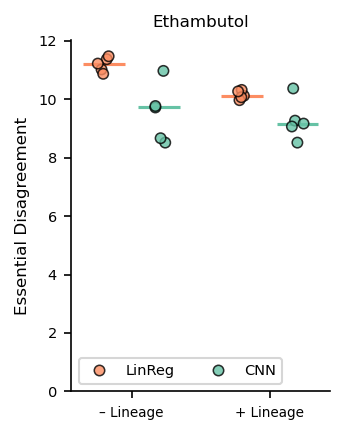

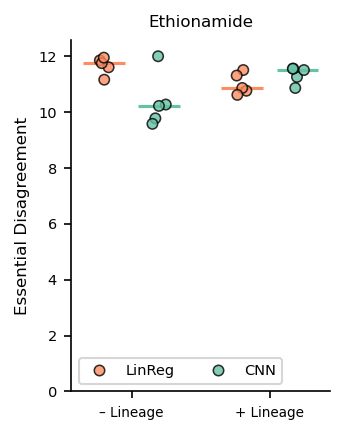

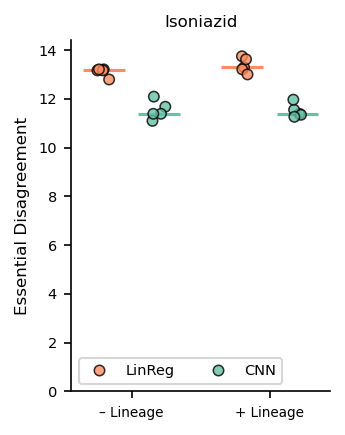

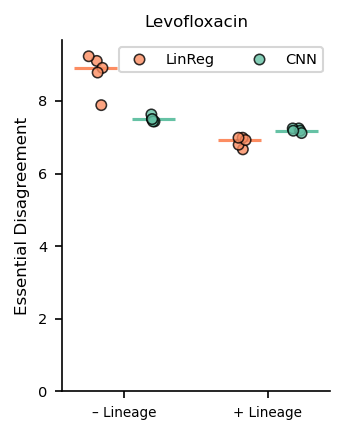

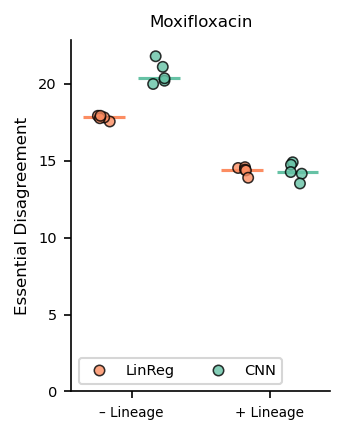

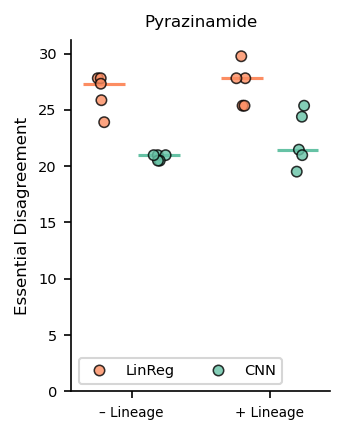

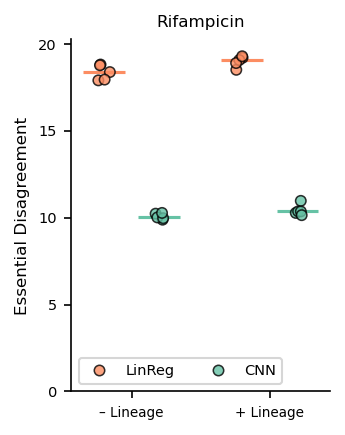

In [103]:
for drug in os.listdir(data_dir):

    if drug in drugs_lst:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        _ = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = ['– Lineage', '+ Lineage'],
                                                      plot_col='Without_doubling', 
                                                      saveName=f"results/{full_drug_name}/EA.svg",
                                                       y_min=0
                                                     )

In [31]:
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.05, 'Asterisk'] = '*'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.01, 'Asterisk'] = '**'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.001, 'Asterisk'] = '***'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.0001, 'Asterisk'] = '****'

In [39]:
df_pvals_combined.query("Variable=='Binned_MAE' & ((Model == '– Lineage' & Drug == 'PZA') | (Model == '+ Lineage' & Drug != 'PZA'))").sort_values("CNN_better_pval")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,RIF,****
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,MXF,****
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,LFX,****
2,+ Lineage,Binned_MAE,0.000001,0.999999,0.000002,INH,****
2,+ Lineage,Binned_MAE,0.000002,0.999998,0.000004,EMB,****
2,+ Lineage,Binned_MAE,0.000008,0.999992,0.000015,BDQ,****
2,+ Lineage,Binned_MAE,0.000043,0.999957,0.000087,ETO,****
0,– Lineage,Binned_MAE,0.000226,0.999774,0.000452,PZA,***


In [40]:
df_pvals_combined.query("Variable=='Without_doubling' & ((Model == '– Lineage' & Drug == 'PZA') | (Model == '+ Lineage' & Drug != 'PZA'))").sort_values("CNN_better_pval").sort_values("Drug")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.000528,0.999472,0.001055,BDQ,***
3,+ Lineage,Without_doubling,0.021668,0.978332,0.043337,EMB,*
3,+ Lineage,Without_doubling,0.920561,0.079439,0.158878,ETO,n
3,+ Lineage,Without_doubling,0.000004,0.999996,0.000008,INH,****
3,+ Lineage,Without_doubling,0.997782,0.002218,0.004436,LFX,n
3,+ Lineage,Without_doubling,0.440659,0.559341,0.881317,MXF,n
1,– Lineage,Without_doubling,0.000663,0.999337,0.001325,PZA,***
3,+ Lineage,Without_doubling,0.0,1.0,0.0,RIF,****


In [21]:
df_pvals_combined.query("Variable=='Binned_MAE'").query("Reg_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk


In [22]:
df_pvals_combined.query("Variable=='Without_doubling'").query("Reg_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.997782,0.002218,0.004436,LFX,n
1,– Lineage,Without_doubling,0.999636,0.000364,0.000729,MXF,n


In [26]:
df_pvals_combined.query("Variable=='Without_doubling'").query("CNN_better_pval > 0.05 & Reg_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.920561,0.079439,0.158878,ETO,n
3,+ Lineage,Without_doubling,0.440659,0.559341,0.881317,MXF,n


In [36]:
for variable in ['Binned_MAE', 'Within_doubling']:

    min_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().min()
    max_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().max()

    print(variable, min_val, max_val)

Binned_MAE 0.1864126013894316 0.7198256541288333
Within_doubling 0.784390243902439 0.9265384615384615


# 2. Pyrazinamide comparison, +/- AA Properties

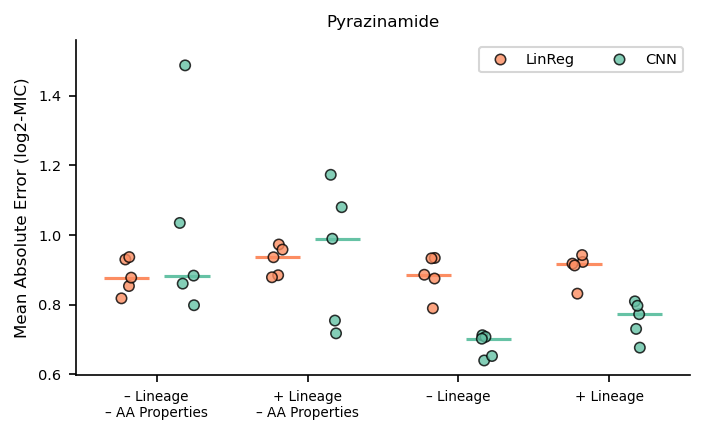

In [6]:
drug = 'PZA'
full_drug_name = abbr_drug_dict[drug]


model_order = ['– Lineage\n– AA Properties',
               '+ Lineage\n– AA Properties',
                '– Lineage', 
               '+ Lineage',
              ]

df_pvals_PZA = get_performance_comparison_CNN_Reg(drug, 
                                                  df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                  model_order=model_order, 
                                                  plot_col='Binned_MAE', 
                                                  # y_min=0, 
                                                  saveName=f"results/{full_drug_name}/MAE_AA_property_compare.svg"
                                                 )

In [7]:
full_drug_name = 'Pyrazinamide'

differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '– Lineage',
                                   '– Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.028403839828585912

In [58]:
full_drug_name = 'Pyrazinamide'

df_combined_all_drugs.query("Drug==@full_drug_name & Model=='CNN' & Addl_Data=='– Lineage'").Binned_MAE.mean() - df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n– AA Properties'].query("Drug==@full_drug_name & Model=='CNN'").Binned_MAE.mean()

-0.33027235934112986

In [8]:
differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '+ Lineage',
                                   '+ Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.053420915776551725

In [10]:
differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '– Lineage',
                                   '+ Lineage',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.018434829160430533

In [13]:
differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '– Lineage\n– AA Properties',
                                   '+ Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.6690830589104699

# 3. Ethionamide Tier 2 Comparison

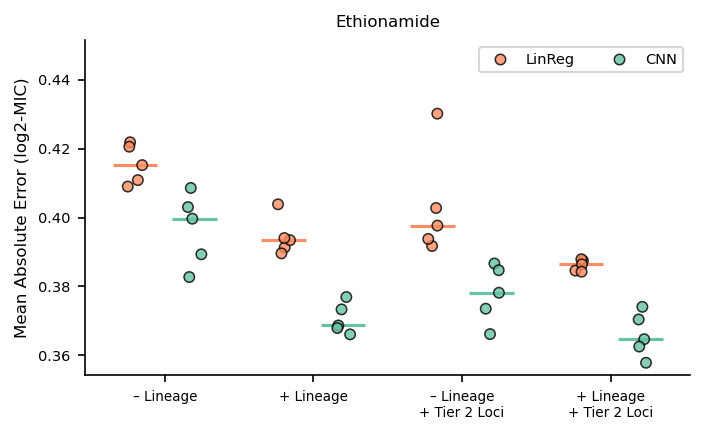

In [110]:
drug = 'ETO'
full_drug_name = abbr_drug_dict[drug]


model_order = ['– Lineage',
               '+ Lineage',
                '– Lineage\n+ Tier 2 Loci', 
               '+ Lineage\n+ Tier 2 Loci',
              ]

df_pvals_ETO = get_performance_comparison_CNN_Reg(drug, 
                                                  df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                  model_order=model_order, 
                                                  plot_col='Binned_MAE', 
                                                  # y_min=0, 
                                                  saveName=f"results/{full_drug_name}/MAE_tier2.svg"
                                                 )

In [121]:
# Tier 2 loci don't significantly improve predictions
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\n+ Tier 2 Loci'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
            df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
             equal_var=False,
            alternative='less'
            )

TtestResult(statistic=-1.3389199376010348, pvalue=0.110898892636907, df=7.113916042175423)

In [122]:
# Tier 2 loci improves predictions over no lineage model
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n+ Tier 2 Loci'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
            df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
             equal_var=False,
            alternative='less'
            )

TtestResult(statistic=-3.1372315382066667, pvalue=0.007367254067246325, df=7.623737788738512)

# Binary Pyrazinamide Model: Compare AUCs +/- Lineage and +/- AA Properties

In [90]:
df_PZA_binary_model_results = get_all_single_drug_models('PZA', regression=True, binary=True)
df_PZA_binary_model_results['Model'] = df_PZA_binary_model_results['Model'].replace('Reg', 'LogReg')

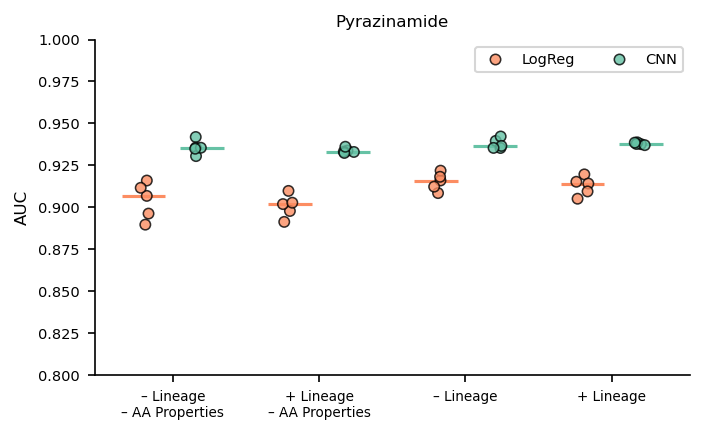

In [91]:
model_order = ['– Lineage\n– AA Properties', '+ Lineage\n– AA Properties', '– Lineage', '+ Lineage']

plot_single_drug_model_comparison('PZA', 
                                  df_PZA_binary_model_results, 
                                  binary=True, 
                                  plot_col='AUC', 
                                  model_order=model_order, 
                                  mean_bar_width=0.15, 
                                  y_min=0.8, 
                                  y_max=1, 
                                  ylabel='AUC', 
                                  title='AUCs of Pyrazinamide Models',
                                  saveName="./results/Pyrazinamide/binary_AUC_comparison.svg",
                                 )  

In [92]:
df_PZA_binary_model_results['Drug'] = 'Pyrazinamide'
df_PZA_binary_model_results['Model'] = df_PZA_binary_model_results['Model'].replace('CNN', 'Binary CNN')

df_PZA_binary_model_results.to_csv("./supplement/binary_pyrazinamide_model_results.csv", index=False)

## Combine into a single supplementary data file and save

In [257]:
df_quant = pd.read_csv("./supplement/quant_model_results.csv")
df_binary = pd.read_csv("./supplement/binary_pyrazinamide_model_results.csv")

df_all_model_results_save = pd.concat([df_quant, df_binary]).rename(columns={'AA': '+ Amino Acid Properties', 'Lineage': '+ Lineage', 'Tier_2': '+ Tier 2 Loci'})

In [258]:
df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains(r'\+ Lineage'), '+ Lineage'] = 1
df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains(r'\– Lineage'), '+ Lineage'] = 0

df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains(r'\+ AA Properties'), '+ Amino Acid Properties'] = 1
df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains(r'\– AA Properties'), '+ Amino Acid Properties'] = 0
df_all_model_results_save.loc[~df_all_model_results_save['Addl_Data'].str.contains('AA Properties'), '+ Amino Acid Properties'] = 1

df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains('Tier 2 Loci'), '+ Tier 2 Loci'] = 1
df_all_model_results_save['+ Tier 2 Loci'] = df_all_model_results_save['+ Tier 2 Loci'].fillna(0)

df_all_model_results_save.loc[df_all_model_results_save['Addl_Data'].str.contains('Binary Augment'), 'Augmented'] = 1
df_all_model_results_save['Augmented'] = df_all_model_results_save['Augmented'].fillna(0)

df_all_model_results_save[['+ Lineage', '+ Amino Acid Properties', '+ Tier 2 Loci', 'Augmented']] = df_all_model_results_save[['+ Lineage', '+ Amino Acid Properties', '+ Tier 2 Loci', 'Augmented']].astype(int)

In [259]:
df_all_model_results_save.Model.unique()

array(['CNN', 'LinReg', 'Binary CNN', 'LogReg'], dtype=object)

In [260]:
del_cols = ['Accuracy', 'Balanced_Acc', 'F1', 'CV', 'Addl_Data', 'Num_Loci', 'Spearman', 'Spearman_pval']

for col in del_cols:
    if col in df_all_model_results_save.columns:
        del df_all_model_results_save[col]

In [261]:
# 5 models of each, yes
df_all_model_results_save.groupby(['Drug', 'Model', '+ Lineage', '+ Tier 2 Loci', '+ Amino Acid Properties', 'Augmented']).count()['Sensitivity'].unique()

array([5])

In [266]:
df_all_model_results_save.query("Model in ['Binary CNN', 'LogReg']").Drug.unique()

array(['Pyrazinamide'], dtype=object)

In [244]:
df_all_model_results_save.query("Augmented==1").Drug.unique()

array(['Bedaquiline'], dtype=object)

In [245]:
df_all_model_results_save.loc[df_all_model_results_save['+ Amino Acid Properties']==0].Drug.unique()

array(['Pyrazinamide'], dtype=object)

In [246]:
df_all_model_results_save.loc[df_all_model_results_save['+ Tier 2 Loci']==1].Drug.unique()

array(['Ethionamide'], dtype=object)

In [264]:
df_all_model_results_save.to_excel("./supplement/Final/Supplementary_Data_3.xlsx", index=False, sheet_name='Model_Results')

In [9]:
st.ttest_ind(df_PZA_binary_model_results.query("Model=='CNN' & Addl_Data=='+ Lineage'")['AUC'],
             df_PZA_binary_model_results.query("Model=='CNN' & Addl_Data=='– Lineage'")['AUC'],
             equal_var=False,
             alternative='two-sided'
            )

TtestResult(statistic=0.08704987175985583, pvalue=0.9344370102488875, df=4.417850208921444)

In [14]:
st.ttest_ind(df_PZA_binary_model_results.query("Model=='CNN' & Addl_Data=='+ Lineage'")['AUC'],
             df_PZA_binary_model_results.query("Model=='LogReg' & Addl_Data=='+ Lineage'")['AUC'],
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=10.037694838999993, pvalue=0.00023808438330895807, df=4.121032555304593)

In [11]:
df_PZA_binary_model_results.query("Model=='CNN' & Addl_Data=='+ Lineage'")['AUC'].mean() - df_PZA_binary_model_results.query("Model=='LogReg' & Addl_Data=='+ Lineage'")['AUC'].mean()

0.025213690334379812

In [26]:
st.ttest_ind(df_PZA_binary_model_results.loc[df_PZA_binary_model_results["Addl_Data"]=='+ Lineage'].query("Model=='CNN'")['AUC'],
             df_PZA_binary_model_results.loc[df_PZA_binary_model_results["Addl_Data"]=='+ Lineage\n– AA Properties'].query("Model=='CNN'")['AUC'],
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=5.977840945602656, pvalue=0.0005772884788385664, df=5.739802932375297)

In [27]:
df_PZA_binary_model_results.loc[df_PZA_binary_model_results["Addl_Data"]=='+ Lineage'].query("Model=='CNN'")['AUC'].mean() - df_PZA_binary_model_results.loc[df_PZA_binary_model_results["Addl_Data"]=='+ Lineage\n– AA Properties'].query("Model=='CNN'")['AUC'].mean()

0.004248174069068078

# MAE Comparison for Defense Presentation

In [8]:
df_quant_comparison = []

for drug in drugs_lst:
    
    drug_full_name = abbr_drug_dict[drug]
    
    if drug == 'BDQ':
        df_quant_comparison.append(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\nBinary Augment'].query("Drug=='Bedaquiline'"))# & Model=='CNN'"))
    else:
        df_quant_comparison.append(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage'].query("Drug==@drug_full_name"))# & Model=='CNN'"))
        
df_quant_comparison = pd.concat(df_quant_comparison)
len(df_quant_comparison)

80

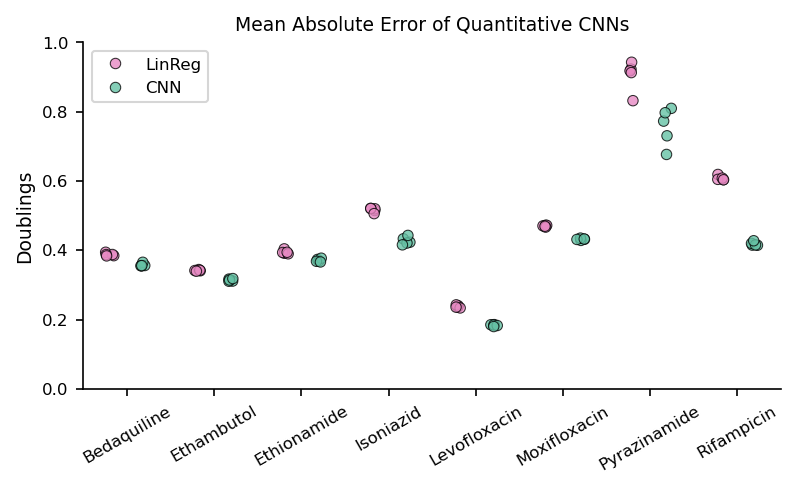

In [22]:
df = df_quant_comparison.copy()
plot_col = 'Binned_MAE'

fig_width = 0.75 * df.Drug.nunique()
fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))

sns.stripplot(data=df,
              x='Drug',
              # order=model_order,
              y=plot_col,
              hue='Model',
              hue_order=['LinReg', 'CNN'],
              palette={'LinReg': sns.color_palette('Set2')[3], 'CNN': sns.color_palette('Set2')[0]},
              dodge=True,
              jitter=True,
              edgecolor='black',
              linewidth=0.5,
              size=5,
              alpha=0.8,
              zorder=1,
              ax=ax,
              # log_scale=2
             )

plt.ylim(0, 1)
plt.xticks(fontsize=8, rotation=30)
plt.yticks(fontsize=8)

plt.xlabel('', fontsize=9)
plt.title('Mean Absolute Error of Quantitative CNNs', fontsize=9)
plt.ylabel('Doublings', fontsize=9)

plt.legend(title=None, fontsize=8, loc='upper left')
sns.despine()
plt.savefig("./results/MAE_quantCNN_vsLinReg_for_defense.svg", bbox_inches='tight')

In [163]:
# df = df_quant_comparison.query("Drug != 'Pyrazinamide'")
# plot_col = 'Within_doubling'

# fig_width = 1.2 * df.Drug.nunique()
# fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))

# sns.stripplot(data=df,
#               x='Drug',
#               # order=model_order,
#               y=plot_col,
#               # hue='Model',
#               # hue_order=[reg_col, 'CNN'],
#               # palette=color_palette,
#               dodge=True,
#               jitter=True,
#               edgecolor='black',
#               linewidth=0.75,
#               size=5,
#               alpha=0.8,
#               zorder=1,
#               ax=ax
#               #log_scale=2
#              )

# for drug in df.Drug.unique():
    
#     cryptic_EA = df_EA_cryptic.query("Drug==@drug").EA_cryptic.values[0]
    
#     ax.errorbar(
#         drug, # x
#         cryptic_EA, # y
#         # xerr=[
#         #     model_data[col_name] - model_data[f'{col_name}_LB'], 
#         #     model_data[f'{col_name}_UB'] - model_data[col_name]
#         # ],
#         fmt='o', 
#         markersize=5,
#         elinewidth=1, 
#         capsize=3,
#         # color=colors[model],
#     )
    
# plt.ylim(0, 1)

In [26]:
def plot_single_drug_model_comparison(drug, df_combined, binary=False, plot_col='Binned_MAE', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    # color_palette = dict(zip(["CNN", "LinReg", "Catalog"], sns.color_palette("Set2").as_hex()))
    if binary:
        reg_col = 'LogReg'
    else:
        reg_col = 'LinReg'

    color_palette = dict(zip(["CNN", reg_col, "Catalog"], [sns.color_palette("Set2").as_hex()[0], sns.color_palette("Set2").as_hex()[1], sns.color_palette("Set2").as_hex()[1]]))

    if model_order is None:
        model_order = ['– Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    # df_combined['Model'] = df_combined['Model'].replace('LinReg', 'Regression')

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=[reg_col, 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate([reg_col, 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    plt.legend(title='', fontsize=ref_font_size-1, loc='best', ncols=2)
    
    # try:
    #     ax.get_legend().remove()
    # except:
    #     pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

# Binary Metrics comparison to WHO-based Predictions

In [100]:
# df_binary = pd.read_excel("analysis/binary_CNN_paper_Supp1.xlsx", sheet_name=None)

# if len(df_binary.keys()) == 1:
#     df_binary = df_binary[list(df_binary.keys())[0]]

In [101]:
# binary_results_drugs_lst = ['RIFAMPICIN', 'ISONIAZID', 'LEVOFLOXACIN', 'MOXIFLOXACIN', 'ETHAMBUTOL', 'ETHIONAMIDE', 'PYRAZINAMIDE']

# df_binary_cnn_summary = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].mean().reset_index()
# df_binary_cnn_summary_std = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].std().reset_index()

# df_quant_cnn_summary = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].mean().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})
# df_quant_cnn_summary_std = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].std().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})

In [14]:
WHO_catalog_sample_counts = pd.read_csv("./analysis/WHO_2023_catalog_samples_summary.csv")

In [15]:
for drug in drugs_lst:
    
    drug_full_name = abbr_drug_dict[drug]
    
    df_phenos = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")
    
    WHO_N = WHO_catalog_sample_counts.query("Drug==@drug_full_name").Genos.values[0]
    CNN_N = len(df_phenos.query("category != 'test_set'"))
    
    print(drug, CNN_N, WHO_N, CNN_N/WHO_N)

BDQ 7301 14135 0.5165192783869826
EMB 7987 45515 0.17548061078765242
ETO 8096 20936 0.38670233091325945
INH 9655 48706 0.1982301975116002
LFX 6240 27576 0.22628372497824195
MXF 7538 22783 0.33086072949128736
PZA 816 21319 0.03827571649702144
RIF 9221 47730 0.19319086528388854


In [2]:
def compute_exact_confidence_intervals(res_df, alpha):
    
    res_df = res_df.reset_index(drop=True)

    # add exact binomial confidence intervals for the binomial variables. The other two will be done in another function
    for i, row in res_df.iterrows():
        
        # will be null for the principal components, so skip them
        if not pd.isnull(row["TP"]):

            # binomtest requires the numbers to be integers
            row[["TP", "FP", "TN", "FN"]] = row[["TP", "FP", "TN", "FN"]].astype(int)
            
            # Sensitivity: TP / (TP + FN)
            ci = st.binomtest(k=row["TP"], n=row["TP"] + row["FN"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Sens_LB", "Sens_UB"]] = [ci.low, ci.high]
            
            # Specificity: TN / (TN + FP)
            ci = st.binomtest(k=row["TN"], n=row["TN"] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Spec_LB", "Spec_UB"]] = [ci.low, ci.high]

            # F1 score: 2TP / (2TP + FN + FP)
            ci = st.binomtest(k=2*row["TP"], n=2*row["TP"] + row['FN'] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["F1_LB", "F1_UB"]] = [ci.low, ci.high]
    
    return res_df


def read_in_process_binary_predictions(model_path, cc):

    df = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv")
    
    # for the binary case:
    if 'y_pred_label' in df.columns:
        return df[['y_test', 'y_pred_label']].rename(columns={'y_pred_label': 'y_pred'})
    else:
        df = df.query("Span_CC==0")

    # have to change names so that we can use the y_pred and y_test column names
    df.rename(columns={'y_test': 'y_test_log2', 'y_pred': 'y_pred_log2'}, inplace=True)

    cc = np.log2(cc)

    df.loc[df['y_test_log2'] > cc, 'y_test'] = 1
    df.loc[df['y_test_log2'] <= cc, 'y_test'] = 0
    
    df.loc[df['y_pred_log2'] > cc, 'y_pred'] = 1
    df.loc[df['y_pred_log2'] <= cc, 'y_pred'] = 0

    return df


def compute_confusion_matrix_values(df):

    df.loc[(df['y_pred']==1) & (df['y_test']==0), 'Group'] = 'FP'
    df.loc[(df['y_pred']==1) & (df['y_test']==1), 'Group'] = 'TP'
    df.loc[(df['y_pred']==0) & (df['y_test']==0), 'Group'] = 'TN'
    df.loc[(df['y_pred']==0) & (df['y_test']==1), 'Group'] = 'FN'

    return pd.DataFrame(df.Group.value_counts()).T

In [3]:
df_binary_statistics_CNN_catalog = []

for drug in drugs_lst:

    if drug in ['PZA']:
        # model_path = f"{drug}_amino_acid"
        model_path = f"{drug}_binary_lineage_amino_acid"
    elif drug == 'BDQ':
        model_path = f"{drug}_augment_lineage_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    cc = cc_dict[drug]

    df_CNN = read_in_process_binary_predictions(model_path, cc)

    # add sensitivity and specificity 95% confidence intervals
    df_CNN = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_CNN), 0.05)
    df_CNN['Drug'] = abbr_drug_dict[drug]
    df_CNN['Model'] = 'CNN'

    df_catalog = pd.read_csv(f"{results_dir}/{model_path.replace('_lineage', '').replace('_amino_acid', '').replace('_augment', '')}/catalog_test_predictions_V2.csv")

    # add sensitivity and specificity 95% confidence intervals
    df_catalog = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_catalog), 0.05)
    df_catalog['Drug'] = abbr_drug_dict[drug]
    df_catalog['Model'] = 'Catalog'

    df_binary_statistics_CNN_catalog.append(df_CNN)
    df_binary_statistics_CNN_catalog.append(df_catalog)

df_binary_statistics_CNN_catalog = pd.concat(df_binary_statistics_CNN_catalog)

# add the overall stats
df_binary_statistics_CNN_catalog['Sens'] = df_binary_statistics_CNN_catalog['TP'] / (df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FN'])
df_binary_statistics_CNN_catalog['Spec'] = df_binary_statistics_CNN_catalog['TN'] / (df_binary_statistics_CNN_catalog['TN'] + df_binary_statistics_CNN_catalog['FP'])

df_binary_statistics_CNN_catalog['F1'] = 2 * df_binary_statistics_CNN_catalog['TP'] / (2 * df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FP'] + df_binary_statistics_CNN_catalog['FN'])
df_binary_statistics_CNN_catalog['Prec'] = df_binary_statistics_CNN_catalog['TP'] / (df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FP'])

In [ ]:
WHO_catalog_sample_counts.query("Drug in @df_binary_statistics_CNN_catalog.Drug").sort_values('Genos')

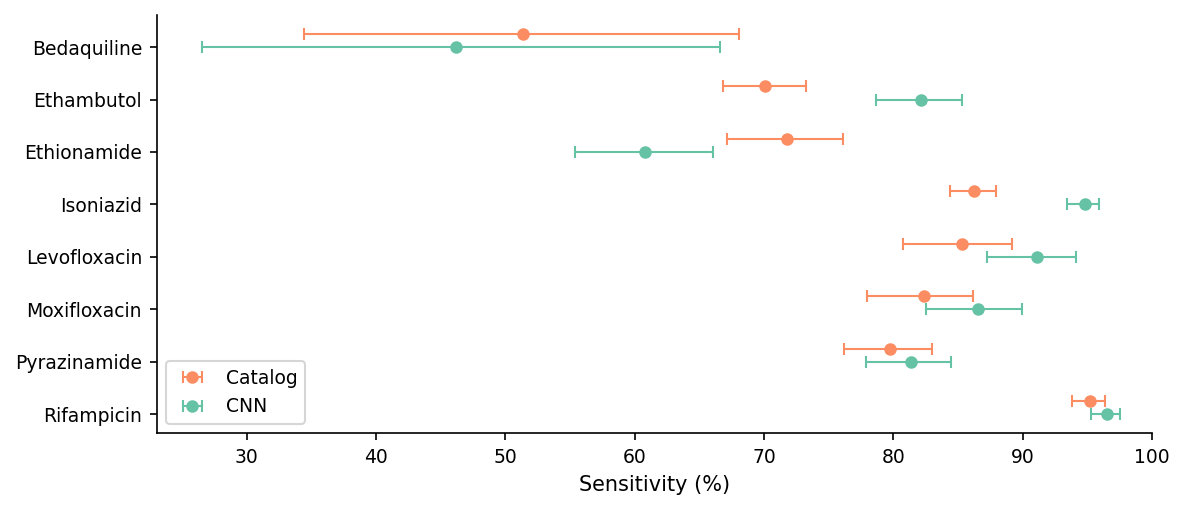

In [28]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Sens', 'Sensitivity (%)', 
                          ['Catalog', 'CNN'], 
                          convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Sensitivity_comparison.svg",
                          legend_loc='lower left'
                         )


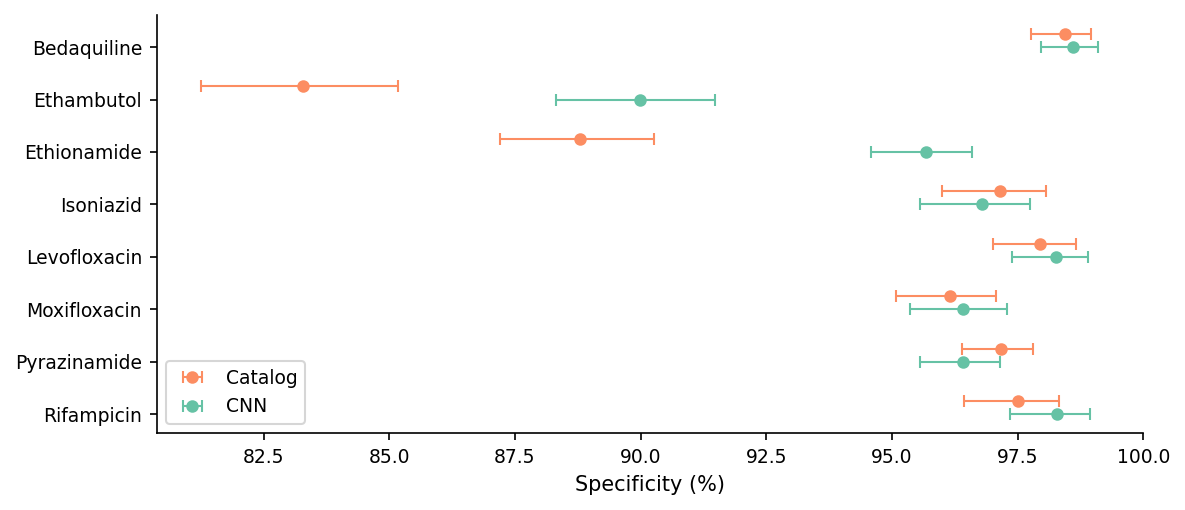

In [29]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Spec', 'Specificity (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Specificity_comparison.svg")


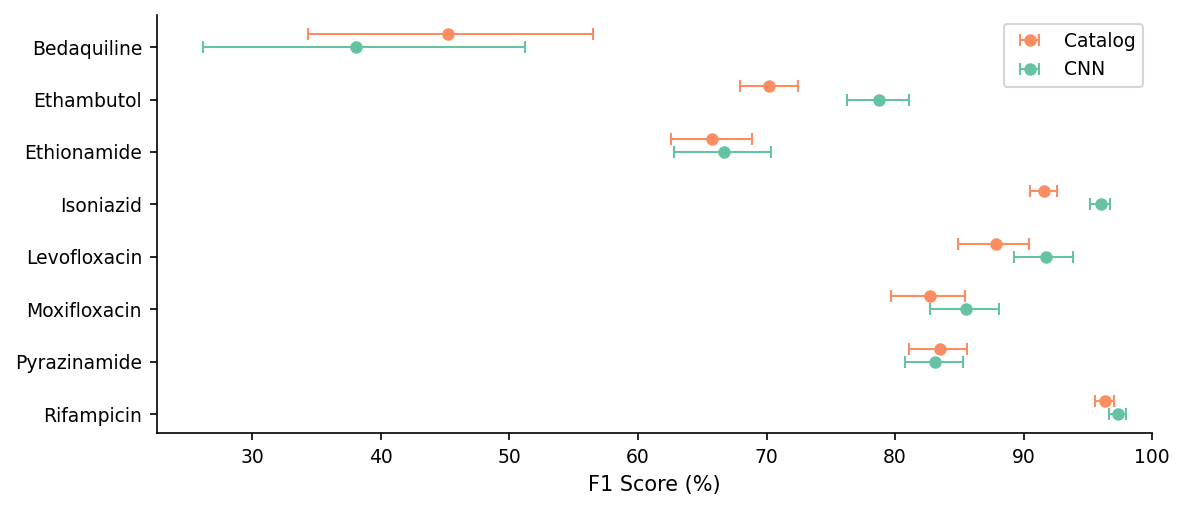

In [274]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'F1', 'F1 Score (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/F1_comparison.svg")

In [4]:
# df_F1_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='F1')
# df_F1_comparison['Diff'] = df_F1_comparison['CNN'] - df_F1_comparison['Catalog']

df_Sens_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Sens')
df_Sens_comparison['Diff'] = df_Sens_comparison['CNN'] - df_Sens_comparison['Catalog']

df_Spec_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Spec')
df_Spec_comparison['Diff'] = df_Spec_comparison['CNN'] - df_Spec_comparison['Catalog']

In [5]:
df_Sens_comparison.Diff.min()*100, df_Sens_comparison.Diff.mean()*100, df_Sens_comparison.Diff.max()*100

(-10.913611210347119, 2.1798718901865852, 12.063892391761243)

In [6]:
df_Spec_comparison.Diff.min()*100, df_Spec_comparison.Diff.mean()*100, df_Spec_comparison.Diff.max()*100

(-0.7525453740593102, 1.746642673107944, 6.8761114404268024)

In [7]:
df_binary_statistics_CNN_catalog.set_index(['Drug', 'Model']).to_csv("./supplement/binary_classification_metrics.csv")

In [22]:
df_Sens_comparison.sort_values('Diff', ascending=False)

Model,CNN,Catalog,Diff
Drug,,,
Ethambutol,0.821494,0.700855,0.120639
Isoniazid,0.947846,0.862046,0.085800
Levofloxacin,0.911263,0.853242,0.058020
Moxifloxacin,0.865330,0.823362,0.041968
Pyrazinamide,0.813499,0.797513,0.015986
Rifampicin,0.965035,0.951947,0.013088
Bedaquiline,0.461538,0.513514,-0.051975
Ethionamide,0.608309,0.717445,-0.109136


In [23]:
df_Spec_comparison.sort_values('Diff', ascending=False)

Model,CNN,Catalog,Diff
Drug,,,
Ethionamide,0.956728,0.887967,0.068761
Ethambutol,0.899862,0.832873,0.066989
Rifampicin,0.982788,0.975043,0.007745
Levofloxacin,0.982636,0.979479,0.003157
Moxifloxacin,0.964193,0.961589,0.002604
Bedaquiline,0.986111,0.984444,0.001667
Isoniazid,0.967919,0.971586,-0.003666
Pyrazinamide,0.964143,0.971669,-0.007525


## Are the sensitivity and specificity differences significant

In [24]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                             alternative='smaller'
                                            )
    
    if pval <= 0.05:
        print(f"{drug} CNN sensitivity less: {pval}")
    else:
        
        _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                                 nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                                 alternative='larger'
                                                )
        
        if pval <= 0.05:
            print(f"{drug} CNN sensitivity greater: {pval}")
    
    # print(drug, pval)

Ethambutol CNN sensitivity greater: 2.255449702912691e-07
Ethionamide CNN sensitivity less: 0.0008259265079300101
Isoniazid CNN sensitivity greater: 1.0011849915578915e-14
Levofloxacin CNN sensitivity greater: 0.014671298538692484


In [15]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                             alternative='larger'
                                            )
    
#     if pval <= 0.05:
#         print(f"{drug} CNN sensitivity less: {pval}")
#     else:
        
#         _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
#                                                  nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
#                                                  alternative='larger'
#                                                 )
        
#         if pval <= 0.05:
#             print(f"{drug} CNN sensitivity greater: {pval}")
    
    print(drug, pval)

Bedaquiline 0.6577217543308761
Ethambutol 2.255449702912691e-07
Ethionamide 0.99917407349207
Isoniazid 1.0011849915578915e-14
Levofloxacin 0.014671298538692484
Moxifloxacin 0.06286371277082009
Pyrazinamide 0.24900643580529525
Rifampicin 0.05625825700610074


In [18]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                             alternative='larger'
                                            )
    
    if pval <= 0.05:
        print(f"{drug} CNN specificity greater: {pval}")
    else:
        
        _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                                 nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                                 alternative='smaller'
                                                )
        
        if pval <= 0.05:
            print(f"{drug} CNN specificity less: {pval}")
    

Ethambutol CNN specificity greater: 5.8722057474915084e-08
Ethionamide CNN specificity greater: 4.258252952601166e-14


In [19]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                             alternative='larger'
                                            )
    
    print(pval, drug)

0.33901642240501356 Bedaquiline
5.8722057474915084e-08 Ethambutol
4.258252952601166e-14 Ethionamide
0.6914574192904337 Isoniazid
0.2799811865945674 Levofloxacin
0.3513103494746057 Moxifloxacin
0.9243547534536929 Pyrazinamide
0.09688848161720942 Rifampicin


# Investigation of CNN Poor Sensitivities

## Pyrazinamide

In [123]:
df_PZA_MIC = pd.read_csv(f"{data_dir}/PZA/data_for_model.csv").query("Span_CC==0")

# df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_PZA_pred = pd.read_csv(f"{results_dir}/PZA_amino_acid/test_predictions.csv").query("Span_CC==0")

df_PZA_pred['y_pred_binary'] = (df_PZA_pred['y_pred'] > np.log2(100)).astype(int)
df_PZA_pred['y_test_binary'] = (df_PZA_pred['y_test'] > np.log2(100)).astype(int)

df_PZA_catalog_pred = pd.read_csv(f"{results_dir}/PZA/catalog_test_predictions_V2.csv")

In [125]:
R_isolates_predicted_S = df_PZA_pred.query("y_pred_binary==0 & y_test_binary==1").Isolate.values

len(R_isolates_predicted_S)

28

In [84]:
variants_in_R_isolates_predicted_S = isolate_variants.query("ROLLINGDB_ID in @R_isolates_predicted_S & drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & ~variant.str.contains('LoF')").variant.unique()

len(variants_in_R_isolates_predicted_S)

16

In [90]:
all_training_variants = isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).variant.unique()
len(all_training_variants)

2021

In [91]:
len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)), len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)) / len(variants_in_R_isolates_predicted_S)

(11, 0.6875)

In [87]:
set(variants_in_R_isolates_predicted_S).intersection(all_training_variants)

{'pncA_c.-11A>T', 'pncA_p.Lys48Thr', 'pncA_p.Thr76Ile', 'pncA_p.Tyr103*'}

In [88]:
total_train_isolates = len(df_PZA_MIC.query("category != 'test_set'"))

In [92]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts()

variant
pncA_p.Lys48Thr    25
pncA_p.Tyr103*      5
pncA_p.Ser67Pro     1
pncA_p.Thr76Ile     1
pncA_c.-11A>T       1
Name: count, dtype: int64

In [94]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates

array([0.03063725, 0.00612745, 0.00122549, 0.00122549, 0.00122549])

In [96]:
(isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates).mean()

0.00808823529411765

### Isolates that CNN correctly predicts susceptible, but the catalog doesn't

In [133]:
S_isolates_CNN_correct_catalog_incorrect = list(set(df_PZA_pred.query("y_pred_binary==0 & y_test_binary==0").Isolate).intersection(df_PZA_catalog_pred.query("y_pred==1 & y_test==0").ROLLINGDB_ID))
len(S_isolates_CNN_correct_catalog_incorrect)

7

In [136]:
isolate_variants.query("ROLLINGDB_ID in @S_isolates_CNN_correct_catalog_incorrect & drug=='Pyrazinamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
112095,SAMN05830711,1364434,C,T,PASS,5087.0,False,0.99,144.0,36.0,60.0,0.0,0.0,missense_variant,sigE,c.22C>T,p.Arg8Trp,sigE_p.Arg8Trp,Pyrazinamide,5) Not assoc w R
112103,SAMN05830711,2289207,T,G,PASS,4190.0,False,1.00,114.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.35A>C,p.Asp12Ala,pncA_p.Asp12Ala,Pyrazinamide,1) Assoc w R
112111,SAMN05830711,4038287,G,A,PASS,4669.0,False,1.00,128.0,36.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
112195,SAMN05915250,2288934,T,C,PASS,5528.0,False,1.00,155.0,36.0,60.0,0.0,0.0,missense_variant,pncA,c.308A>G,p.Tyr103Cys,pncA_p.Tyr103Cys,Pyrazinamide,1) Assoc w R
119541,SAMN05916331,2289099,T,G,PASS,1886.0,False,0.98,55.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.143A>C,p.Lys48Thr,pncA_p.Lys48Thr,Pyrazinamide,2) Assoc w R - Interim
119544,SAMN05916331,4038287,G,A,PASS,1777.0,False,1.00,49.0,36.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
122582,SAMN05916424,2289099,T,G,PASS,1532.0,False,1.00,38.0,40.0,60.0,0.0,0.0,missense_variant,pncA,c.143A>C,p.Lys48Thr,pncA_p.Lys48Thr,Pyrazinamide,2) Assoc w R - Interim
122585,SAMN05916424,4038287,G,A,PASS,638.0,False,1.00,16.0,40.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
132450,SAMN05918717,2170692,A,C,PASS,2599.0,False,1.00,71.0,37.0,60.0,0.0,0.0,intergenic_region,PPE35-Rv1919c,n.2170692A>C,NaN,PPE35_c.-80T>G,Pyrazinamide,3) Uncertain significance
132453,SAMN05918717,2288717,C,T,PASS,2541.0,False,0.99,71.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.525G>A,p.Met175Ile,pncA_p.Met175Ile,Pyrazinamide,2) Assoc w R - Interim


## Ethionamide

In [11]:
df_ETO_MIC = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv").query("Span_CC==0")

df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_ETO_pred = pd.read_csv(f"{results_dir}/ETO_amino_acid/test_predictions.csv").query("Span_CC==0")

df_ETO_pred_lineage['y_pred_binary'] = (df_ETO_pred_lineage['y_pred'] > np.log2(5)).astype(int)
df_ETO_pred_lineage['y_test_binary'] = (df_ETO_pred_lineage['y_test'] > np.log2(5)).astype(int)

df_ETO_catalog_pred = pd.read_csv(f"{results_dir}/ETO/catalog_test_predictions_V2.csv")

In [12]:
# CNN_missed_ETO_R_isolates = df_ETO_pred_lineage.query("y_pred_binary == 0 & y_test_binary == 1").Isolate.values

# subset to the ones that the model didn't predict as leading to resistance in test isolates
# ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @CNN_missed_ETO_R_isolates & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @df_ETO_MIC.ROLLINGDB_ID & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

len(ETO_resistance_variants)

194

In [13]:
df_ETO_MIC_by_resistance_variant = []

for variant in ETO_resistance_variants:

    MICs_isolates_with_variant = isolate_variants.query("variant==@variant").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').ETO_midpoint.values
    df_ETO_MIC_by_resistance_variant.append(pd.DataFrame({'variant': variant, 'MIC': MICs_isolates_with_variant}))

df_ETO_MIC_by_resistance_variant = pd.concat(df_ETO_MIC_by_resistance_variant)

# add counts to sort by
df_ETO_MIC_by_resistance_variant = df_ETO_MIC_by_resistance_variant.merge(df_ETO_MIC_by_resistance_variant.groupby("variant").count().rename(columns={'MIC': 'Count'}).reset_index())

In [22]:
isolate_variants.query("variant=='inhA_c.-777C>T'").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').query("ETO_upper_bound <= 2")#[['ETO_lower_bound', 'ETO_midpoint', 'category']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
1166,SAMEA7546458,1673425,C,T,Amb,487.0,False,0.66,41.0,34.0,...,lam,NaN,4.3/LAM,0.006857,4,-7.188276,0,0.0,4-0,train_set
1170,SAMEA7546477,1673425,C,T,Amb,25.0,False,0.25,89.0,35.0,...,lam,NaN,4.3/LAM,0.007266,4,-7.104527,0,0.0,4-0,train_set


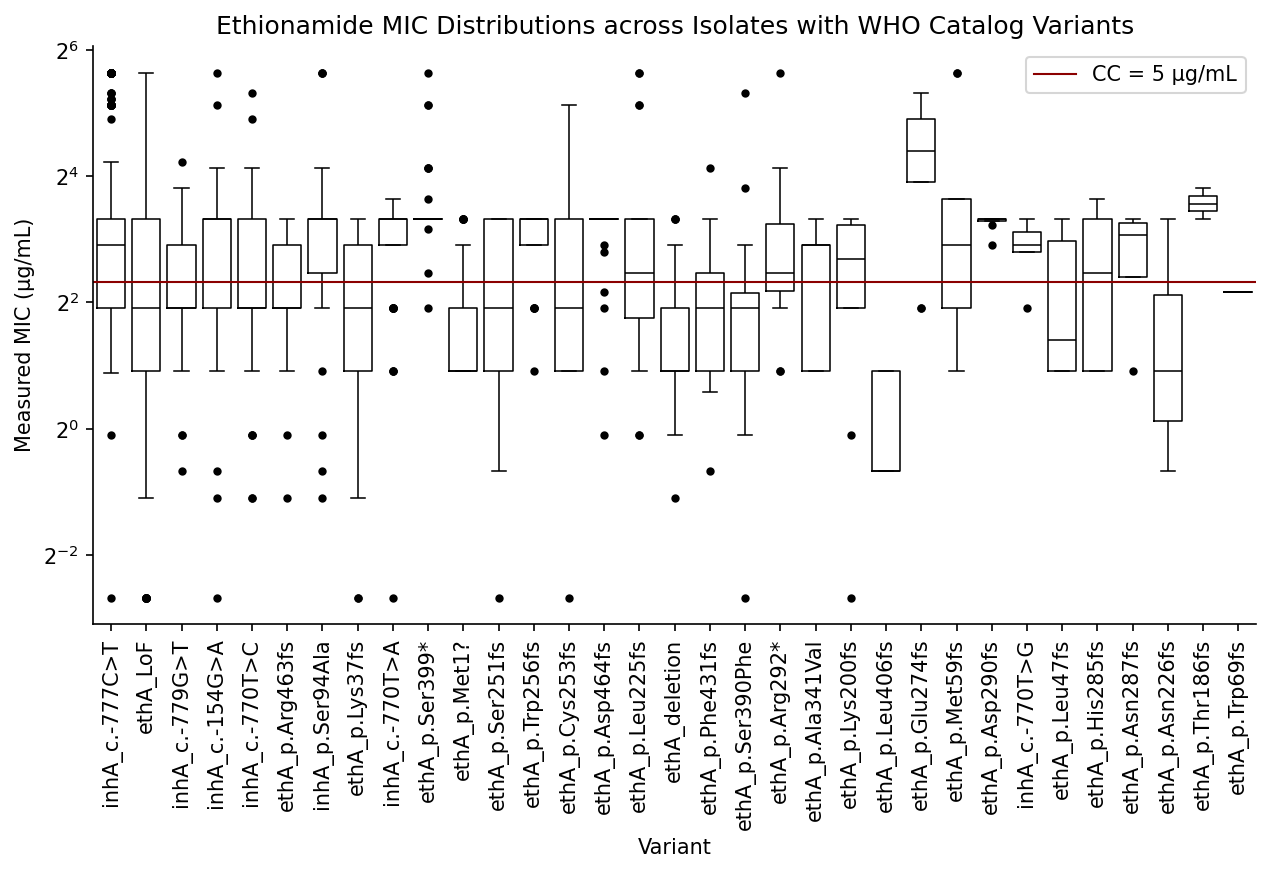

In [106]:
# keep the first 35 variants
keep_variants = df_ETO_MIC_by_resistance_variant.drop_duplicates(subset='Count').sort_values("Count", ascending=False).variant.values[:35]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_ETO_MIC_by_resistance_variant.query("variant in @keep_variants").sort_values("Count", ascending=False),
            x='variant',
            y='MIC',
            log_scale=2,
            whis=1,
            fliersize=3,
            fill=False,
            color='black',
            linewidth=0.75,
            flierprops={"markerfacecolor": "black"},
           )

plt.axhline(5, color='darkred', linewidth=1, label = "CC = 5 µg/mL")
plt.xticks(rotation=90)
plt.legend()
plt.ylabel('Measured MIC (µg/mL)')
plt.xlabel('Variant')
plt.title("Ethionamide MIC Distributions across Isolates with WHO Catalog Variants")

sns.despine()
plt.savefig("./MtbQuantCNN/results/Ethionamide/MIC_distributions_by_WHO_variant.svg", bbox_inches='tight')

# Loss Curves

Plot validation loss for the 5 CV replicates and the actual model on top. 

In [120]:
def plot_histories(path, exclude_num_patience_epochs=200, cv=True, saveName=None):

    if cv:
        combined_replicates = [pd.read_csv(fName)[['val_loss']] for fName in glob.glob(os.path.join(path, f"cross_validation/history*.csv"))]
    
    history = pd.read_csv(os.path.join(path, "history.csv"))

    if exclude_num_patience_epochs != 0:
        history = history.iloc[:-exclude_num_patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    if cv:
        for i, single_rep in enumerate(combined_replicates):

            if exclude_num_patience_epochs !=  0:
                single_rep = single_rep.iloc[:-exclude_num_patience_epochs, :]
                
            print(f"Trained replicate {i} for {len(single_rep)} epochs")
            
            plt.plot(single_rep.index.values + 1, single_rep['val_loss'], color="lightgray")

    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)
    print(f"Trained full model for {len(history)} epochs")

    plt.xlabel("Epoch", fontsize=10)
    plt.ylabel("Validation Loss", fontsize=10)
    
    plot_title = "Validation Loss" + " for " + os.path.basename(path) + " Model"
    plt.title(plot_title, fontsize=12)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName)

Trained replicate 0 for 305 epochs
Trained replicate 1 for 308 epochs
Trained replicate 2 for 301 epochs
Trained replicate 3 for 293 epochs
Trained replicate 4 for 296 epochs
Trained full model for 295 epochs


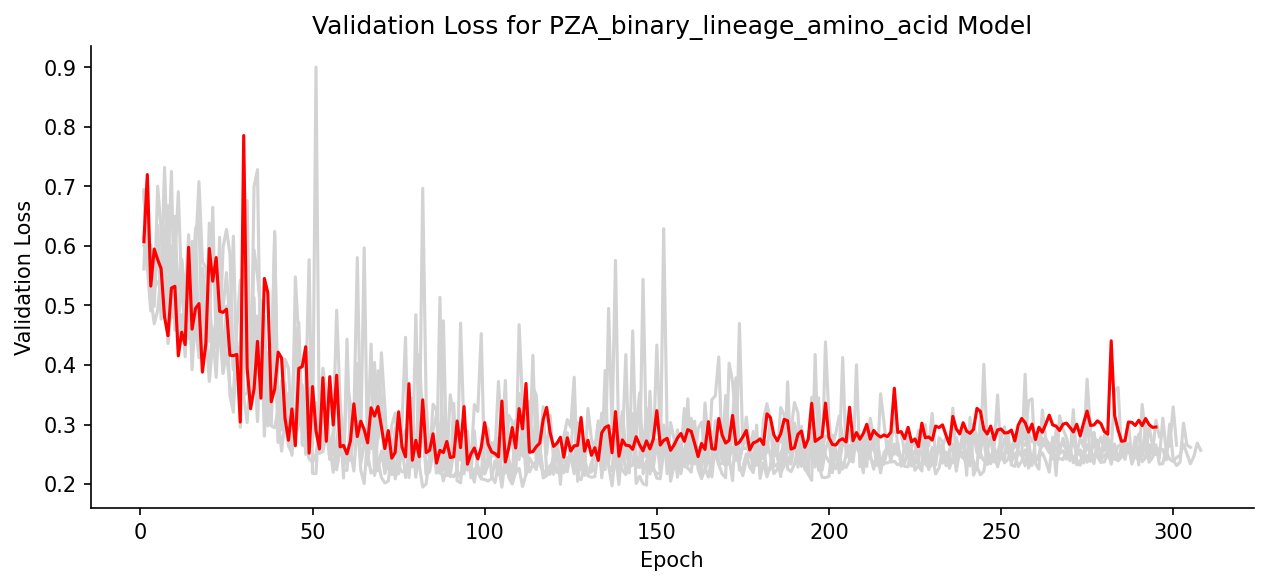

In [123]:
drug = 'PZA'
plot_histories(os.path.join(results_dir, f'{drug}_binary_lineage_amino_acid'), exclude_num_patience_epochs=0, cv=True, saveName=f"results/{abbr_drug_dict[drug]}/binary_loss_curves.svg")


BDQ
Trained replicate 0 for 482 epochs
Trained replicate 1 for 499 epochs
Trained replicate 2 for 419 epochs
Trained replicate 3 for 623 epochs
Trained replicate 4 for 809 epochs
Trained full model for 262 epochs

EMB
Trained replicate 0 for 302 epochs
Trained replicate 1 for 190 epochs
Trained replicate 2 for 233 epochs
Trained replicate 3 for 220 epochs
Trained replicate 4 for 429 epochs
Trained full model for 277 epochs

ETO
Trained replicate 0 for 223 epochs
Trained replicate 1 for 304 epochs
Trained replicate 2 for 243 epochs
Trained replicate 3 for 212 epochs
Trained replicate 4 for 606 epochs
Trained full model for 393 epochs

INH
Trained replicate 0 for 374 epochs
Trained replicate 1 for 342 epochs
Trained replicate 2 for 359 epochs
Trained replicate 3 for 242 epochs
Trained replicate 4 for 568 epochs
Trained full model for 407 epochs

LFX
Trained replicate 0 for 375 epochs
Trained replicate 1 for 194 epochs
Trained replicate 2 for 457 epochs
Trained replicate 3 for 232 epochs

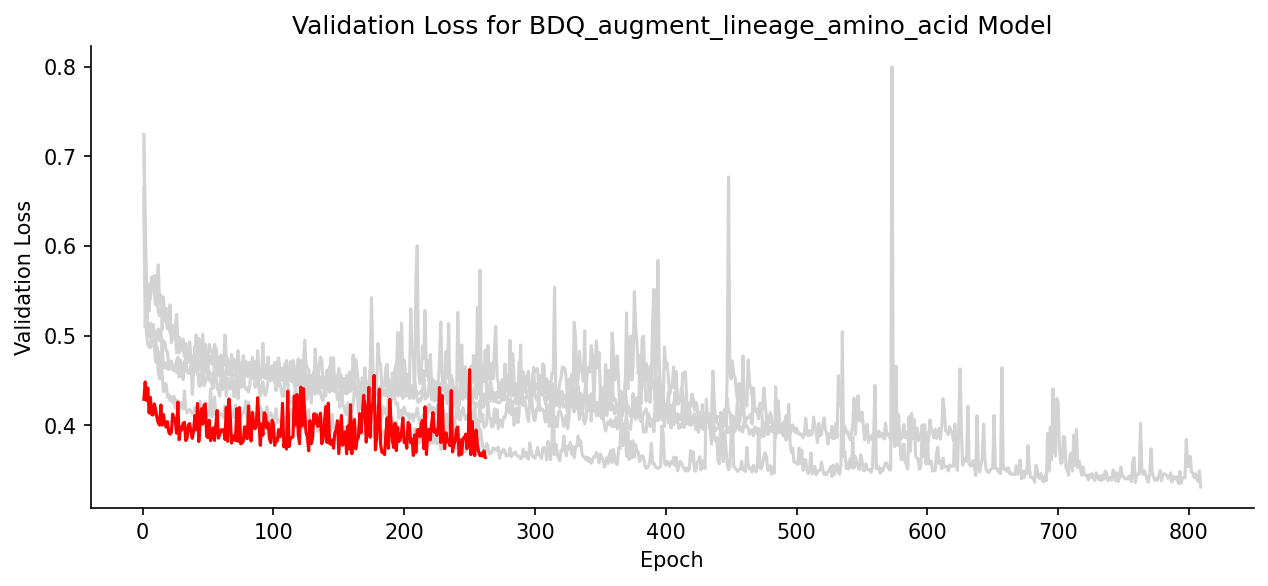

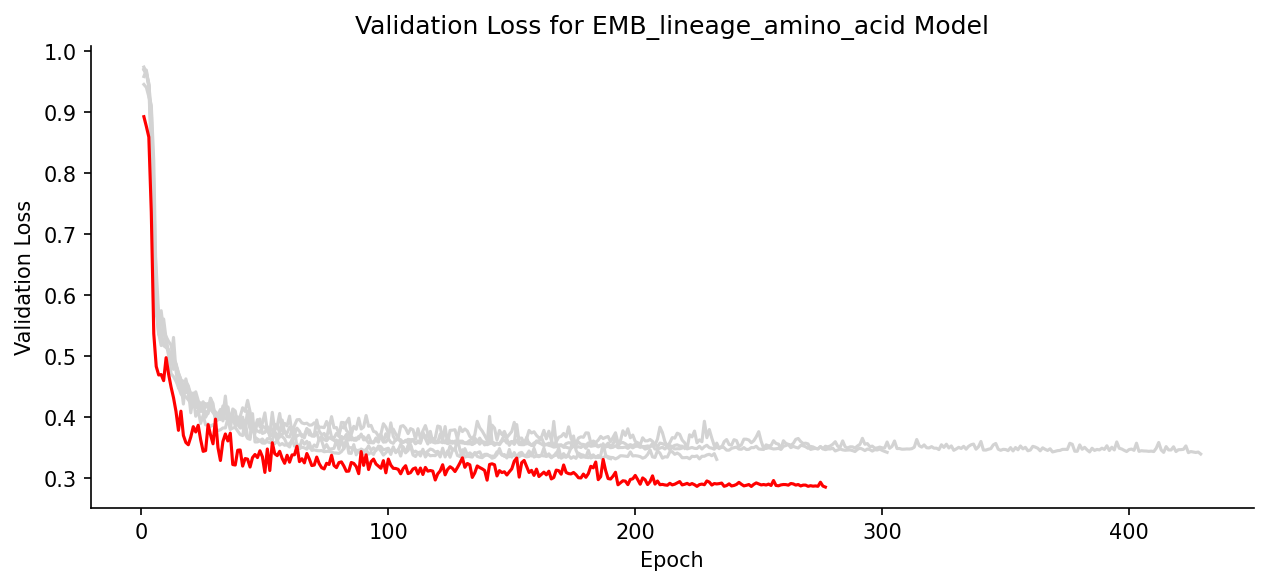

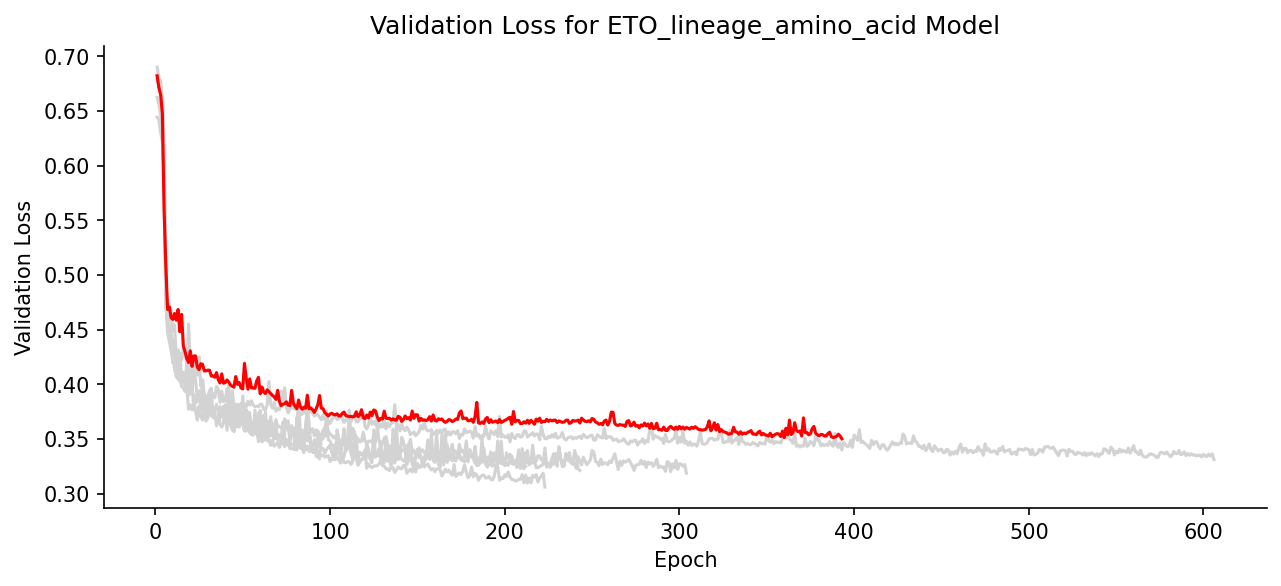

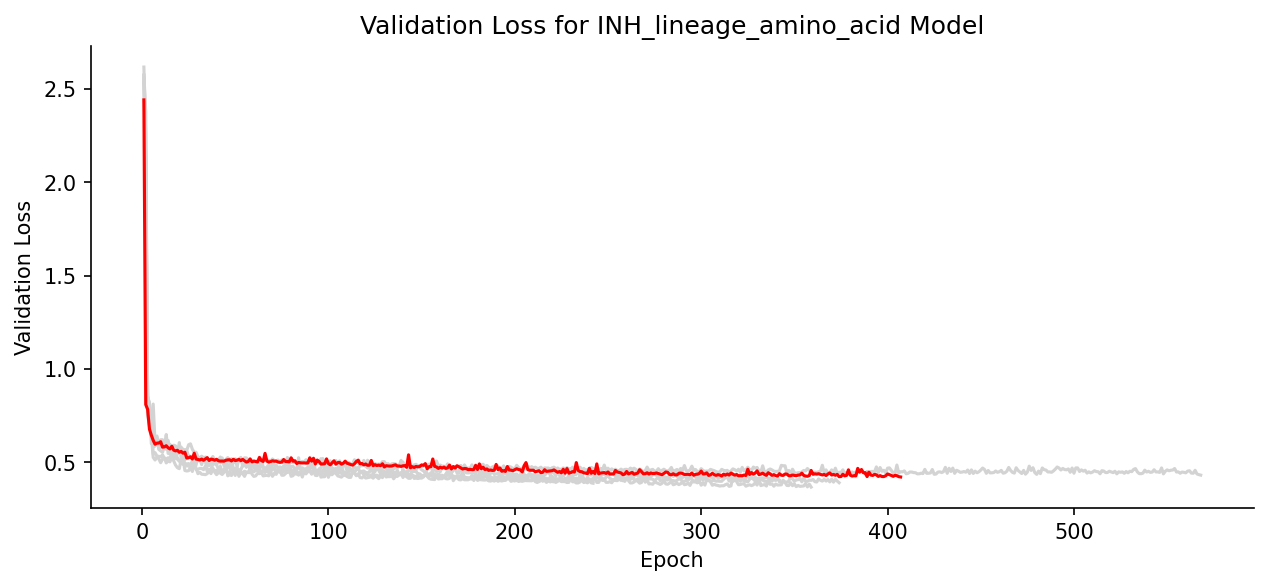

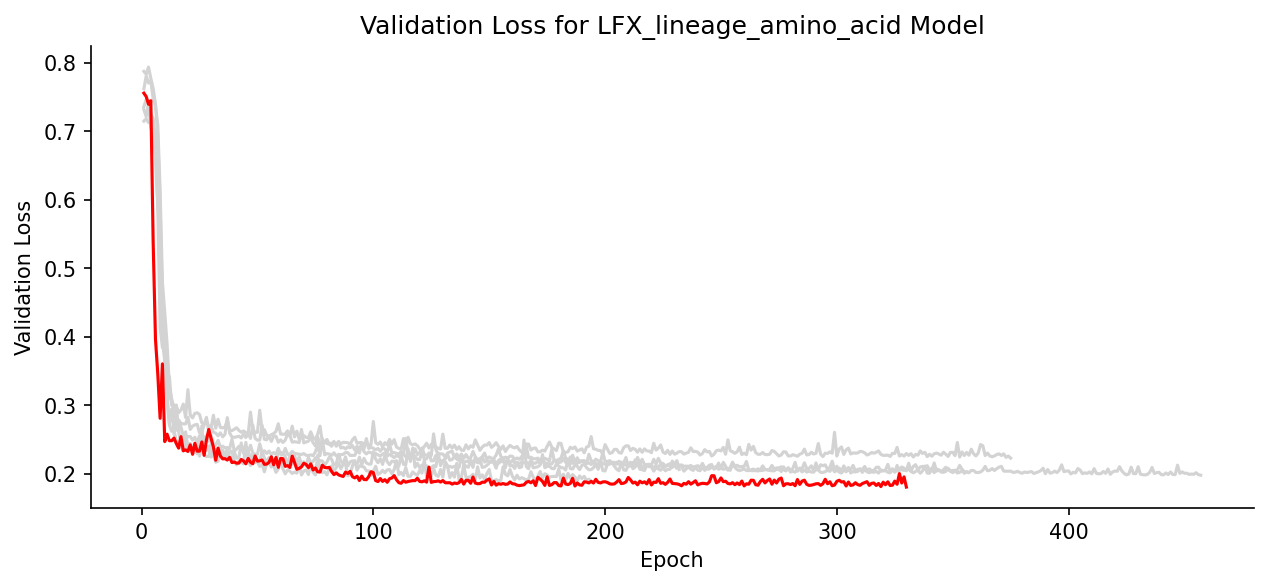

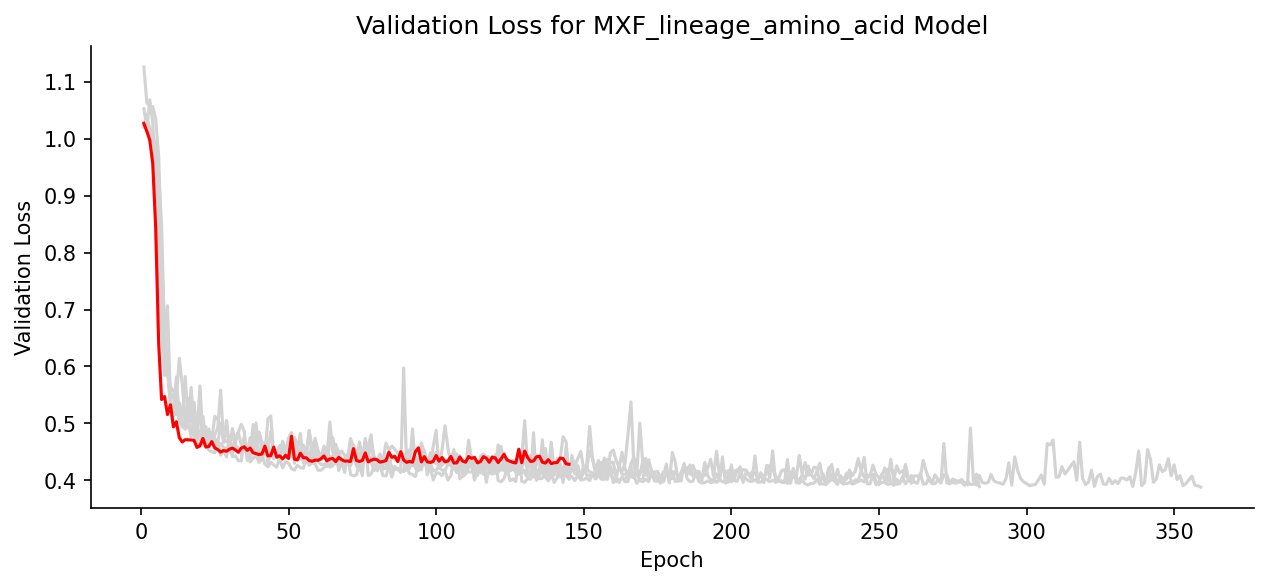

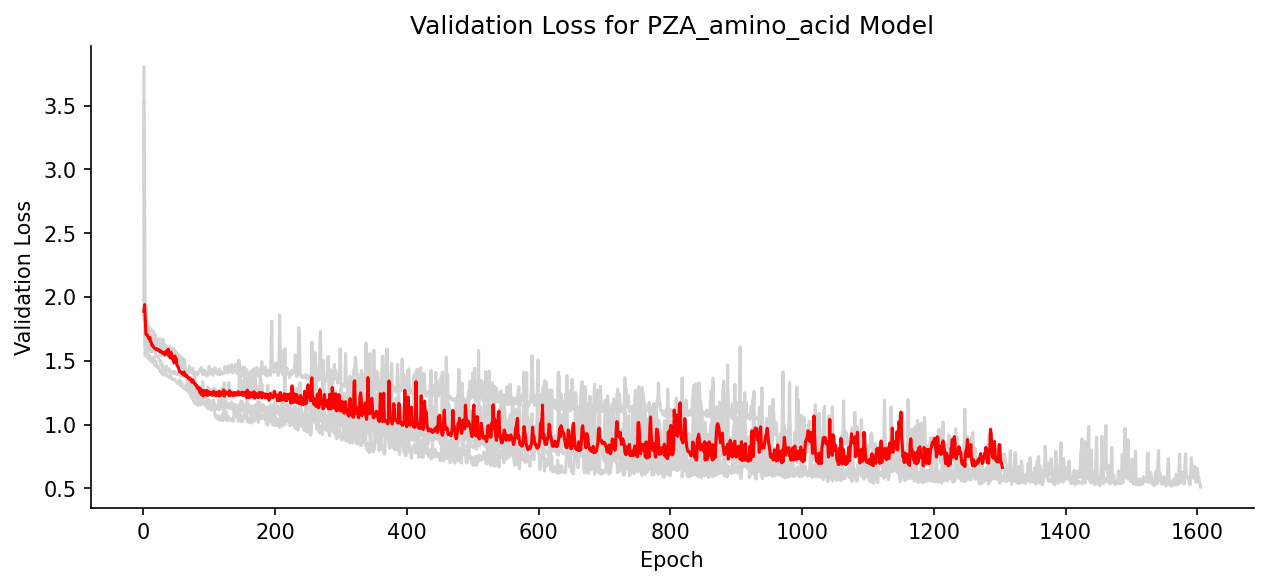

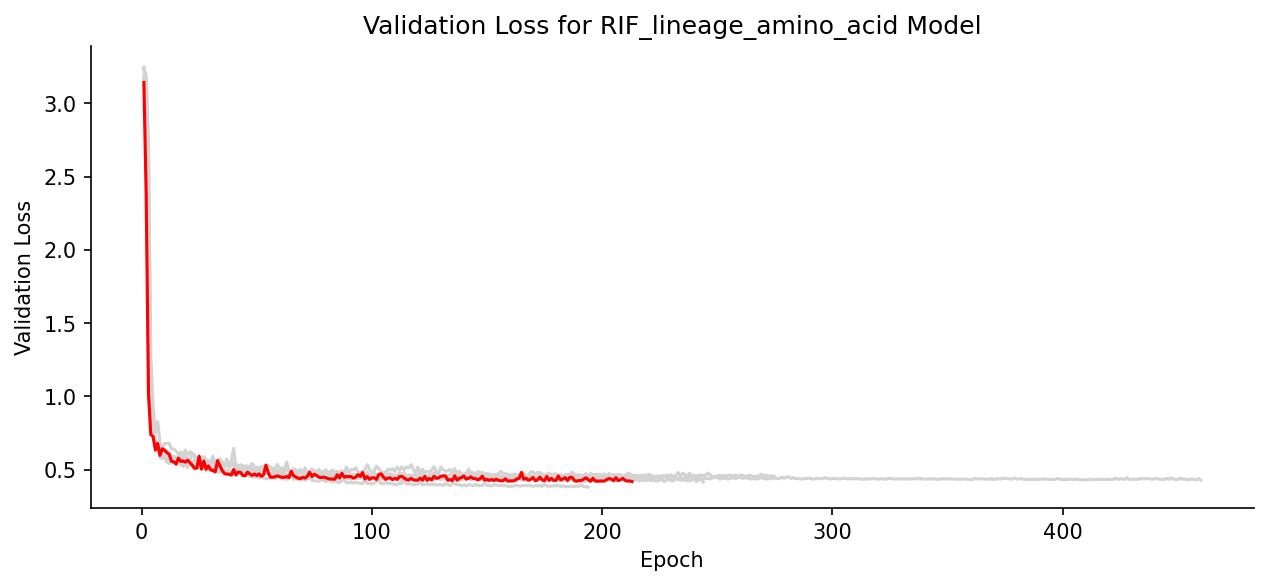

In [119]:
for drug in drugs_lst:
    
    print(f"\n{drug}")

    if drug == 'PZA':
        model_path = 'PZA_amino_acid'
    elif drug == 'BDQ':
        model_path = 'BDQ_augment_lineage_amino_acid'
    else:
        model_path = f'{drug}_lineage_amino_acid'
    
    plot_histories(os.path.join(results_dir, model_path), patience_epochs=200, cv=True, saveName=f"results/{abbr_drug_dict[drug]}/loss_curves.svg")

# After BDQ Augmentation, do the test predictions generally change?

## Want to make sure that there isn't a general shift to larger predicted MICs

In [23]:
df_BDQ = pd.read_csv(f"{data_dir}/BDQ_augment/data_for_model.csv")

df_test = pd.read_csv(f"{results_dir}/BDQ_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_test_augmented = pd.read_csv(f"{results_dir}/BDQ_augment_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")

df_test = df_test.merge(df_test_augmented[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_pred_augmented'}))
df_test['Resistant'] = (df_test['lower'] >= 0.25).astype(int)

df_test['y_pred_exp'] = np.exp2(df_test['y_pred'])
df_test['y_pred_augmented_exp'] = np.exp2(df_test['y_pred_augmented'])

df_test['diff'] = df_test['y_pred_augmented'] - df_test['y_pred']
df_test['diff_exp'] = df_test['y_pred_augmented_exp'] - df_test['y_pred_exp']

df_test['FC_exp'] = df_test['y_pred_augmented_exp'] / df_test['y_pred_exp']
df_test['log2_FC_exp'] = np.log2(df_test['FC_exp'])

df_test_susceptible = df_test.query("upper <= 0.25")
len(df_test), len(df_test_susceptible)

(1826, 1800)

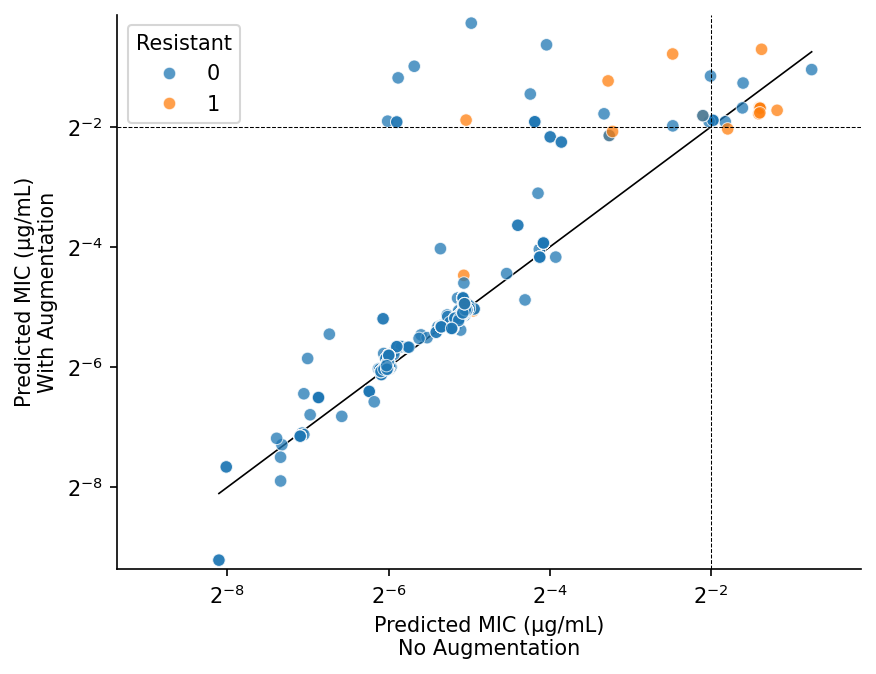

In [3]:
sns.scatterplot(data=df_test,
                x='y_pred_exp',
                y='y_pred_augmented_exp',
                alpha=0.75,
                hue='Resistant'
               )

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.plot(np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         color='black',
         zorder=0,
         linewidth=0.8,
        )

plt.axhline(y=0.25, linestyle='--', color='black', linewidth=0.5)
plt.axvline(x=0.25, linestyle='--', color='black', linewidth=0.5)

max_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.max()
min_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.min()

plt.xlim(min_val*0.9, max_val*1.1)
plt.ylim(min_val*0.9, max_val*1.1)

plt.xlabel('Predicted MIC (µg/mL)\nNo Augmentation')
plt.ylabel('Predicted MIC (µg/mL)\nWith Augmentation')

sns.despine()
plt.savefig("./results/Bedaquiline/test_predictions_augmentation_compare.svg", bbox_inches='tight')

In [71]:
# use non-parametric test rather than parametric because the augmentation should only affect isolates with resistance mutations
# so the shift in predicted MICs is expected to affect only certain isolates, so the difference between predictions isn't expected to be symmetric about 0 
st.wilcoxon(df_test['y_pred_augmented_exp'],
            df_test['y_pred_exp'],
            alternative='greater'
           )

WilcoxonResult(statistic=799934.0, pvalue=0.9352075721697812)

In [11]:
st.wilcoxon(df_test.query("Resistant==1")['y_pred_exp'],
            df_test.query("Resistant==1")['y_pred_augmented_exp'],
            alternative='less'
           )

WilcoxonResult(statistic=158.0, pvalue=0.3354863077402115)

In [33]:
st.wilcoxon(df_test.query("lower >= 0.12")['y_pred_exp'],
            df_test.query("lower >= 0.12")['y_pred_augmented_exp'],
            alternative='less'
           )

WilcoxonResult(statistic=990.0, pvalue=0.0007955525027321129)

In [39]:
print(len(df_test.query("y_pred_augmented_exp >= 0.25")))

st.wilcoxon(df_test.query("y_pred_augmented_exp >= 0.25")['y_pred_exp'],
            df_test.query("y_pred_augmented_exp >= 0.25")['y_pred_augmented_exp'],
            alternative='less'
           )

37


WilcoxonResult(statistic=145.0, pvalue=0.0006739664459018968)

In [48]:
df_BDQ_no_augment = df_BDQ.query("DB_OF_ORIGIN!='WHO_catalog_binary' & category=='train_set'")

isolate_variants.query("ROLLINGDB_ID in @df_BDQ_no_augment.ROLLINGDB_ID & drug=='Bedaquiline' & confidence=='1) Assoc w R' & variant != 'Rv0678_LoF' & ~variant.str.contains('fs')").ROLLINGDB_ID.nunique()

5

In [51]:
isolate_variants.query("ROLLINGDB_ID in @df_BDQ_no_augment.ROLLINGDB_ID & drug=='Bedaquiline' & confidence=='1) Assoc w R' & variant != 'Rv0678_LoF' & ~variant.str.contains('fs')").merge(df_BDQ_no_augment[['ROLLINGDB_ID', 'BDQ_lower_bound']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,BDQ_lower_bound
0,SAMEA1102223,779350,G,A,PASS,2011.0,False,1.00,62.0,32.0,...,0.0,0.0,missense_variant,Rv0678,c.361G>A,p.Gly121Arg,Rv0678_p.Gly121Arg,Bedaquiline,1) Assoc w R,0.25
1,SAMEA7526308,779339,T,G,PASS,1845.0,False,1.00,53.0,35.0,...,0.0,0.0,missense_variant,Rv0678,c.350T>G,p.Leu117Arg,Rv0678_p.Leu117Arg,Bedaquiline,1) Assoc w R,0.12
2,SAMEA7555815,779339,T,G,PASS,4212.0,False,0.95,154.0,34.0,...,0.0,0.0,missense_variant,Rv0678,c.350T>G,p.Leu117Arg,Rv0678_p.Leu117Arg,Bedaquiline,1) Assoc w R,0.03
3,SAMEA7562380,779339,T,G,PASS,2558.0,False,0.93,106.0,34.0,...,0.0,0.0,missense_variant,Rv0678,c.350T>G,p.Leu117Arg,Rv0678_p.Leu117Arg,Bedaquiline,1) Assoc w R,0.12
4,SAMEA8718809,779350,G,A,Amb,355.0,False,0.73,117.0,36.0,...,0.0,0.0,missense_variant,Rv0678,c.361G>A,p.Gly121Arg,Rv0678_p.Gly121Arg,Bedaquiline,1) Assoc w R,0.12
